# **Projet d'Analyse de Données : 2024-2025**

# **Partie 1 :**

**L’objectif** est de mener une analyse approfondie des données clients fournies par le service marketing d’une institution bancaire afin de modéliser les facteurs prédictifs du churn. L’enjeu est de détecter les segments à risque de désengagement et de concevoir des stratégies d’intervention ciblées, visant à optimiser la rétention client et à améliorer les indicateurs de fidélisation.

1- Chargement de la base de données :

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
Bank=pd.read_csv('Bank.csv')

In [ ]:
Bank

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.999910
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.999940
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.999980
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.999870
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.999980
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,772366833,Existing Customer,50,M,2,Graduate,Single,$40K - $60K,Blue,40,...,4003.0,1851,2152.0,0.703,15476,117,0.857,0.462,0.000191,0.999810
10123,710638233,Attrited Customer,41,M,2,Unknown,Divorced,$40K - $60K,Blue,25,...,4277.0,2186,2091.0,0.804,8764,69,0.683,0.511,0.995270,0.004729
10124,716506083,Attrited Customer,44,F,1,High School,Married,Less than $40K,Blue,36,...,5409.0,0,5409.0,0.819,10291,60,0.818,0.000,0.997880,0.002118
10125,717406983,Attrited Customer,30,M,2,Graduate,Unknown,$40K - $60K,Blue,36,...,5281.0,0,5281.0,0.535,8395,62,0.722,0.000,0.996710,0.003294


In [ ]:
Bank.rename(columns={
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1': 'NBC1'
}, inplace=True)

In [ ]:
Bank.rename(columns={
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2': 'NBC2'
}, inplace=True)

In [ ]:
# Statistiques descriptives pour les variables quantitatives
print("\nRésumé statistique :")
Bank.describe()


Résumé statistique :


,CLIENTNUM,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,NBC1,NBC2
count,1.012700e+04,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,7.391776e+08,46.325960,2.346203,35.928409,3.812580,2.341167,2.455317,8631.953698,1162.814061,7469.139637,0.759941,4404.086304,64.858695,0.712222,0.274894,0.159997,0.840003
std,3.690378e+07,8.016814,1.298908,7.986416,1.554408,1.010622,1.106225,9088.776650,814.987335,9090.685324,0.219207,3397.129254,23.472570,0.238086,0.275691,0.365301,0.365301
min,7.080821e+08,26.000000,0.000000,13.000000,1.000000,0.000000,0.000000,1438.300000,0.000000,3.000000,0.000000,510.000000,10.000000,0.000000,0.000000,0.000008,0.000420
25%,7.130368e+08,41.000000,1.000000,31.000000,3.000000,2.000000,2.000000,2555.000000,359.000000,1324.500000,0.631000,2155.500000,45.000000,0.582000,0.023000,0.000099,0.999660
50%,7.179264e+08,46.000000,2.000000,36.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000,3474.000000,0.736000,3899.000000,67.000000,0.702000,0.176000,0.000181,0.999820
75%,7.731435e+08,52.000000,3.000000,40.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000,9859.000000,0.859000,4741.000000,81.000000,0.818000,0.503000,0.000337,0.999900
max,8.283431e+08,73.000000,5.000000,56.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000,34516.000000,3.397000,18484.000000,139.000000,3.714000,0.999000,0.999580,0.999990


Le tableau ci-joint présente les statistiques descriptives des variables quantitatives issues de la base de données. Nous constatons ainsi que l’âge moyen des clients est de 46 ans, avec une ancienneté moyenne dans la banque de 36,9 mois. La limite de crédit est d’environ 8 832 mais présente une dispersion importante, preuve de la diversité des profils. La moyenne des montants de transactions est de 4 404 pour environ 65 transactions par client. Le ratio moyen d’utilisation du crédit est de 27 % ce qui indique que les clients n’utilisent qu’une partie de leur crédit. Sur les autres variables, le nombre de contacts ou le nombre de relations également présente une certaine disparité d’où il ressort une diversité de la clientèle.

In [ ]:
# Statistiques pour les variables qualitatives
for col in Bank.select_dtypes(include='object'):
    print(Bank[col].value_counts(normalize=True)*100)

Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64
Gender
F    52.908068
M    47.091932
Name: proportion, dtype: float64
Education_Level
Graduate         30.887726
High School      19.877555
Unknown          14.999506
Uneducated       14.683519
College          10.002962
Post-Graduate     5.095290
Doctorate         4.453441
Name: proportion, dtype: float64
Marital_Status
Married     46.282216
Single      38.935519
Unknown      7.396070
Divorced     7.386195
Name: proportion, dtype: float64
Income_Category
Less than $40K    35.163425
$40K - $60K       17.675521
$80K - $120K      15.157500
$60K - $80K       13.844179
Unknown           10.980547
$120K +            7.178829
Name: proportion, dtype: float64
Card_Category
Blue        93.176656
Silver       5.480399
Gold         1.145453
Platinum     0.197492
Name: proportion, dtype: float64


Au sein de la population étudiée, on constate que 83,9 % des clients sont encore actifs, et la répartition en termes de sexe est relativement équilibrée avec 52,9 % de femmes. Le niveau d’éducation des clients est hautement l’université avec 30,9 % de diplômés d’un Graduate, puis on retrouve les diplômés des lycées avec 19,9 % de personnes. Il faut signaler la faible proportion de titulaires de doctorat. Concernant leur statut matrimonial, 46,3 % des clients sont mariés mais une faible proportion est encore célibataire (39 %). Précisons que 35,2 % des clients gagnent moins de 40 000 $ et que la carte la plus répandue chez eux reste la Carte Bleue à 93,2 %. L’ensemble de ces résultats sous-entend que bien qu’il s’agit d’une clientèle plutôt variée, plusieurs tendances se dessinent en effet selon certains critères sociodémographiques.

In [ ]:
Bank.shape

(10127, 23)

In [ ]:
Bank.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10127 entries, 0 to 10126
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   CLIENTNUM                 10127 non-null  int64  
 1   Attrition_Flag            10127 non-null  object 
 2   Customer_Age              10127 non-null  int64  
 3   Gender                    10127 non-null  object 
 4   Dependent_count           10127 non-null  int64  
 5   Education_Level           10127 non-null  object 
 6   Marital_Status            10127 non-null  object 
 7   Income_Category           10127 non-null  object 
 8   Card_Category             10127 non-null  object 
 9   Months_on_book            10127 non-null  int64  
 10  Total_Relationship_Count  10127 non-null  int64  
 11  Months_Inactive_12_mon    10127 non-null  int64  
 12  Contacts_Count_12_mon     10127 non-null  int64  
 13  Credit_Limit              10127 non-null  float64
 14  Total_

La base de données présente 23 colonnes, principalement de type numérique (int64 et float64) et de type catégorique (objet). Voici une analyse par type :
Variables numériques entières (int64)
CLIENTNUM, Customer_Age, Dependent_count, Months_on_book, Total_Relationship_Count, Months_Inactive_12_mon, Contacts_Count_12_mon, Total_Revolving_Bal, Total_Trans_Amt, Total_Trans_Ct
Ces variables représentent des quantités discrètes (par exemple l'âge, le nombre de contacts, les montants) ou des identifiants (CLIENTNUM).

Variables numériques continues (float64)
Credit_Limit, Avg_Open_To_Buy, Total_Amt_Chng_Q4_Q1, Total_Ct_Chng_Q4_Q1, Avg_Utilization_Ratio, NBC, NBC 2
Ces colonnes contiennent des valeurs continues (fourchettes de montants, ratios, variations), le type float64 est donc approprié.

Variables catégorielles (objet)
Attrition_Flag, Gender, Education_Level, Marital_Status, Income_Category, Card_Category
Ces colonnes correspondent à des étiquettes qualitatives ou à des catégories. Toutefois, pour un traitement plus efficace dans le cadre de l'apprentissage automatique, il serait souhaitable de les convertir en catégories ou par le biais d'un encodage (par exemple, encodage en un seul point ou encodage d'étiquettes).

In [ ]:
Bank.isnull().sum()

,0
CLIENTNUM,0
Attrition_Flag,0
Customer_Age,0
Gender,0
Dependent_count,0
Education_Level,0
Marital_Status,0
Income_Category,0
Card_Category,0
Months_on_book,0


On constate que toutes les colonnes contiennent 0 valeur nulle, soit aucune valeur manquante dans le jeu de données. C'est une excellente situation pour l'analyse des données ou la mise au point d'un modèle de machine learning, dans la mesure où elle évite les étapes de traitement ou d'imputation des valeurs manquantes.

Les valeurs aberrantes

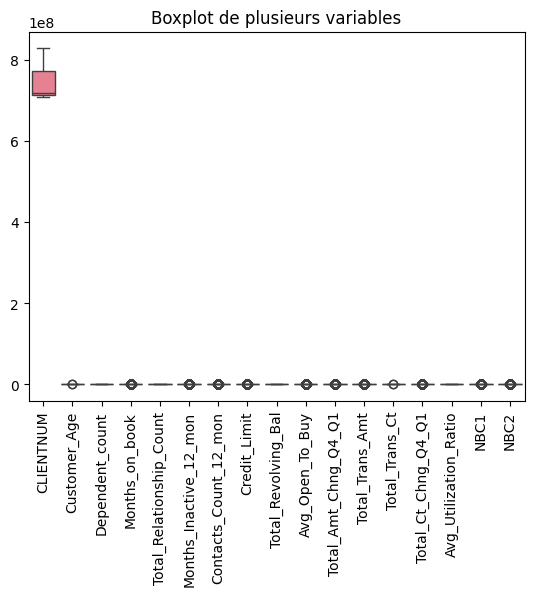

In [ ]:
# Sélection des colonnes numériques
colonnes_numeriques = Bank.select_dtypes(include=['number'])

# Création du boxplot
sns.boxplot(data=colonnes_numeriques)
plt.xticks(rotation=90)  # Pour éviter que les noms de colonnes se chevauchent
plt.title("Boxplot de plusieurs variables")
plt.show()

Le diagramme en boîte présente plusieurs variables numériques d'un ensemble de données, la variable CLIENTNUM étant complètement déséquilibrée. Cette variable, connue pour être un identifiant de client, prend des valeurs très élevées et écrase visuellement toutes les autres. Elle ne fournit aucune information utile à l'analyse, et la meilleure façon de procéder est donc de la supprimer. Une fois qu'elle aura été supprimée, nous pourrons enfin voir les vraies différences entre les autres variables : leurs médianes, leur dispersion et même identifier les valeurs extrêmes. Le tableau sera beaucoup plus clair et plus facile à lire.

In [ ]:
# Suppression de la colonne CLIENTNUM
Bank_sans_id = Bank.drop(columns=['CLIENTNUM'])

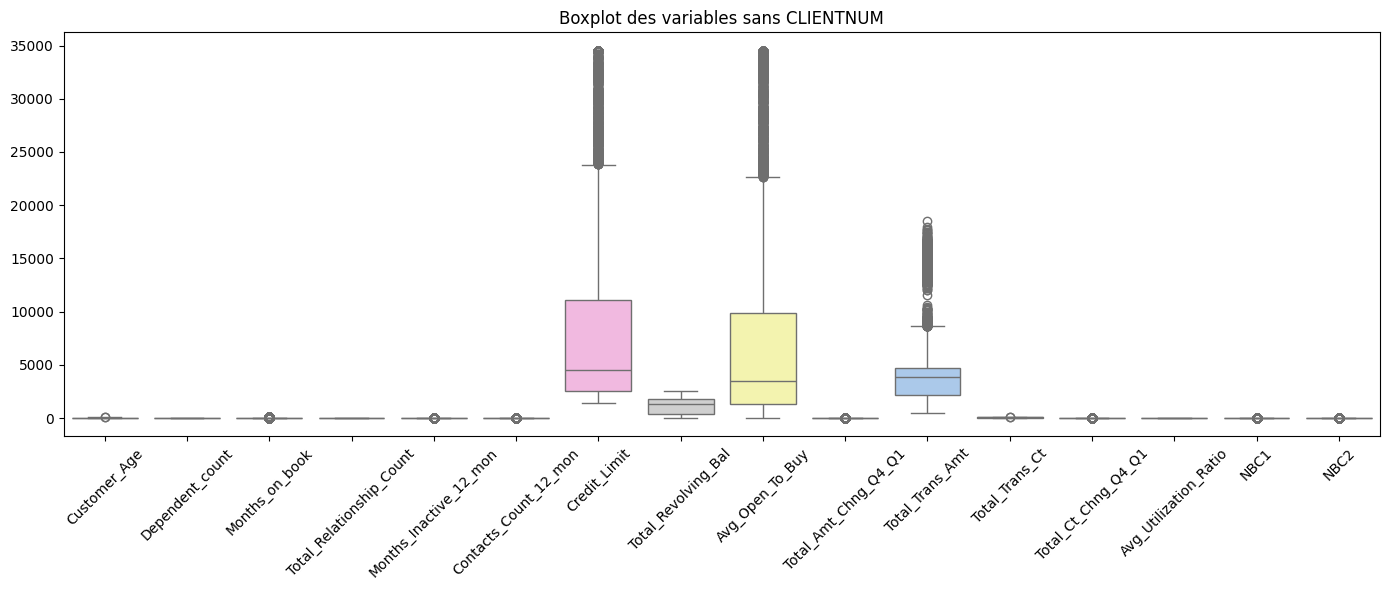

In [ ]:
# Affichage du boxplot
plt.figure(figsize=(14, 6))
sns.boxplot(data=Bank_sans_id, palette='pastel')
plt.title('Boxplot des variables sans CLIENTNUM')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Après avoir mis de côté CLIENTNUM, la variable dominante sans valeur explicative, le boxplot retrouve naturellement un espace de respiration où toutes les variables peuvent enfin s'exprimer. Des colonnes comme Credit_Limit, Avg_Open_To_Buy et Total_Trans_Amt prennent de la hauteur avec de nombreuses valeurs atypiques, révélant une forte dispersion, tandis que d'autres comme Customer_Age ou Total_Ct_Chng_Q4_Q1 font preuve de sagesse et restent concentrées autour de leur médiane. Il convient de noter que ce graphique reflète la base de données avant toute standardisation ou normalisation, ceci expliquant les différences d'échelle marquées entre les variables.

In [ ]:
from sklearn.preprocessing import StandardScaler

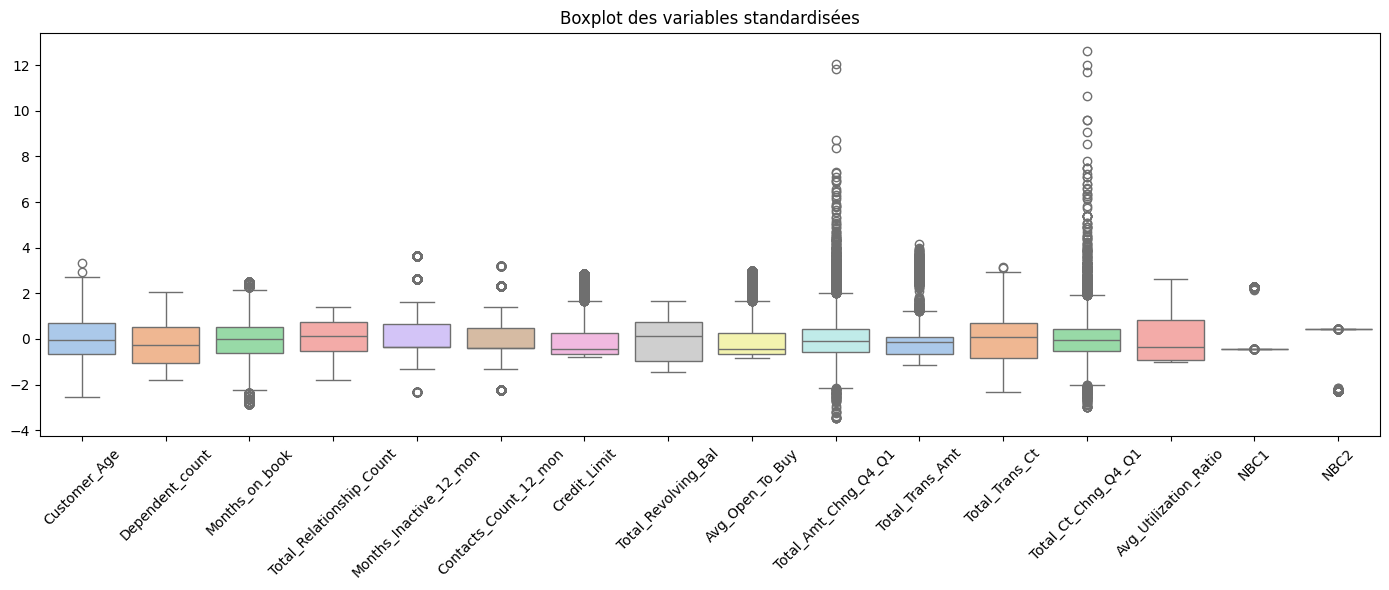

In [ ]:
# Standardisation
# Select only numeric features for scaling
numeric_features = Bank_sans_id.select_dtypes(include=np.number).columns
scaler = StandardScaler()
Bank_standard = pd.DataFrame(scaler.fit_transform(Bank_sans_id[numeric_features]), columns=numeric_features)

# Boxplot
plt.figure(figsize=(14,6))
sns.boxplot(data=Bank_standard, palette='pastel')
plt.title("Boxplot des variables standardisées")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Après la standardisation, les variables sont toutes mises à la même échelle : en tournant autour de zéro, elles ont à peu près la même « largeur » de dispersion. Ainsi la comparaison des variables entre elles est plus facile, et aucune variable ayant des chiffres importants n'écrase les autres. Sur ce diagramme en boîte, on constate qu'il existe encore des valeurs extrêmes (appelées « outliers ») qui se distinguent pour certaines variables, telles que Total_Trans_Amt ou Total_Amt_Chng_Q4_Q1. Globalement, le graphique indique que les données sont prêtes pour des analyses plus précises et plus équilibrées.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

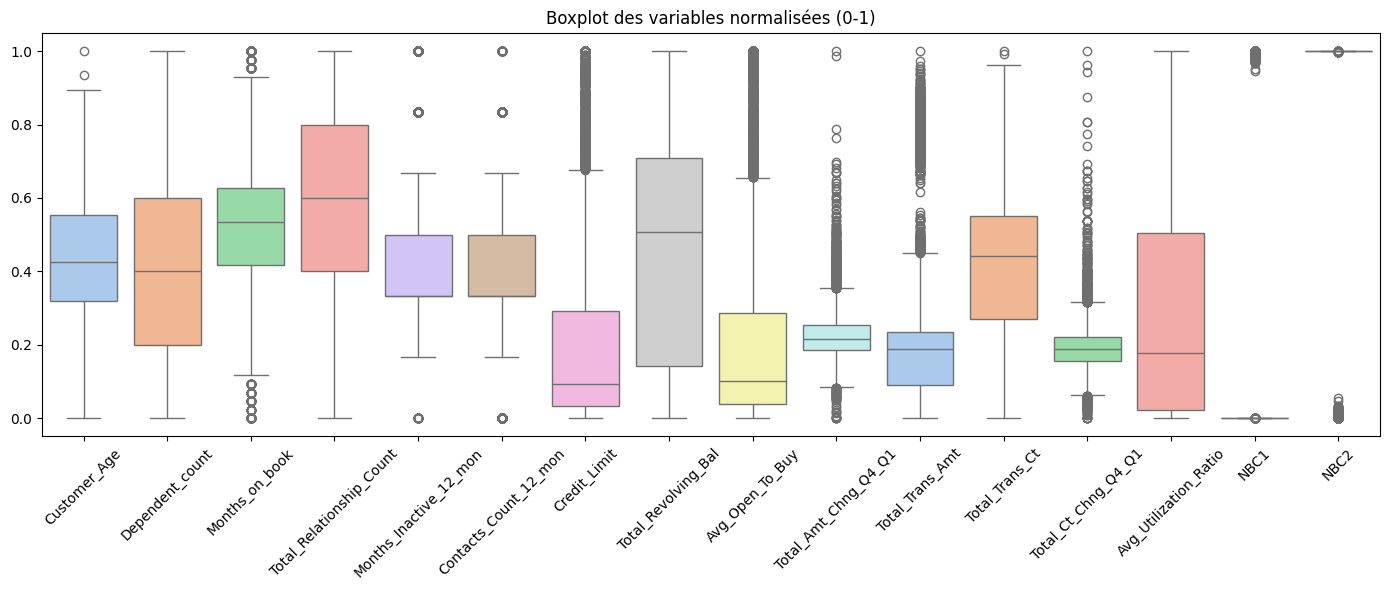

In [ ]:
# Normalisation
scaler = MinMaxScaler()

# Select only numeric features for scaling
numeric_features = Bank_sans_id.select_dtypes(include=np.number).columns

# Fit and transform on numeric features only
Bank_normalized = pd.DataFrame(scaler.fit_transform(Bank_sans_id[numeric_features]), columns=numeric_features, index=Bank_sans_id.index)

# Concatenate normalized numeric features with non-numeric features
Bank_normalized = pd.concat([Bank_normalized, Bank_sans_id.drop(columns=numeric_features)], axis=1)


# Boxplot
plt.figure(figsize=(14,6))
sns.boxplot(data=Bank_normalized[numeric_features], palette='pastel') # Plot only numeric features
plt.title("Boxplot des variables normalisées (0-1)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Tout comme pour la standardisation, la normalisation permet de ramener les variables à une échelle commune entre 0 et 1, ce afin de pouvoir comparer directement leurs distributions sans aucune influence de leur nature initiale. Le diagramme en boîte qui en résulte met en évidence des différences significatives entre les variables en termes de dispersion, de symétrie et de présence de valeurs extrêmes. Les variables telles que Months_on_book, Customer_Age ou Total_Relationship_Count ont une distribution relativement équilibrée, indiquant une homogénéité dans les données. D'autres, comme Credit_Limit et Avg_Open_To_Buy, montrent une asymétrie importante, la majorité des valeurs étant regroupées vers les niveaux inférieurs, ce qui suggère que peu de clients bénéficient de limites de crédit élevées. Pour les variables telles que Total_Trans_Amt, Total_Ct_Chng_Q4_Q1 ou Total_Amt_Chng_Q4_Q1, de nombreuses valeurs atypiques sont très présentes, indiquant une grande hétérogénéité des comportements d'achat ou des changements de montants entre les individus. A l'inverse, NBC et NBC_2 affichent très peu de variabilité, suggérant qu'ils sont probablement binaires ou peu informatifs. Ce graphique permet donc d'identifier les variables qui méritent une attention particulière dans les étapes ultérieures de l'analyse, notamment en ce qui concerne la réduction des dimensions, le choix des variables pertinentes et la gestion des valeurs aberrantes.

In [ ]:
Bank_normalized

,Customer_Age,Dependent_count,Months_on_book,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,...,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,NBC1,NBC2,Attrition_Flag,Gender,Education_Level,Marital_Status,Income_Category,Card_Category
0,0.404255,0.6,0.604651,0.8,0.166667,0.500000,0.340190,0.308701,0.345116,0.392994,...,0.437534,0.061061,0.000086,0.999920,Existing Customer,M,High School,Married,$60K - $80K,Blue
1,0.489362,1.0,0.720930,1.0,0.166667,0.333333,0.206112,0.343266,0.214093,0.453636,...,1.000000,0.105105,0.000049,0.999950,Existing Customer,F,Graduate,Single,Less than $40K,Blue
2,0.531915,0.6,0.534884,0.6,0.166667,0.000000,0.059850,0.000000,0.098948,0.763615,...,0.628164,0.000000,0.000013,0.999990,Existing Customer,M,Graduate,Married,$80K - $120K,Blue
3,0.297872,0.8,0.488372,0.4,0.666667,0.166667,0.056676,1.000000,0.022977,0.413600,...,0.628164,0.760761,0.000126,0.999880,Existing Customer,F,High School,Unknown,Less than $40K,Blue
4,0.297872,0.6,0.186047,0.8,0.166667,0.000000,0.099091,0.000000,0.136557,0.640271,...,0.673129,0.000000,0.000014,0.999990,Existing Customer,M,Uneducated,Married,$60K - $80K,Blue
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10122,0.510638,0.4,0.627907,0.4,0.333333,0.500000,0.077536,0.735399,0.062266,0.206947,...,0.230749,0.462462,0.000184,0.999820,Existing Customer,M,Graduate,Single,$40K - $60K,Blue
10123,0.319149,0.4,0.279070,0.6,0.333333,0.500000,0.085819,0.868494,0.060499,0.236679,...,0.183899,0.511512,0.995688,0.004311,Attrited Customer,M,Unknown,Divorced,$40K - $60K,Blue
10124,0.382979,0.2,0.534884,0.8,0.500000,0.666667,0.120042,0.000000,0.156637,0.241095,...,0.220248,0.000000,0.998299,0.001699,Attrited Customer,F,High School,Married,Less than $40K,Blue
10125,0.085106,0.4,0.534884,0.6,0.500000,0.500000,0.116172,0.000000,0.152928,0.157492,...,0.194400,0.000000,0.997129,0.002875,Attrited Customer,M,Graduate,Unknown,$40K - $60K,Blue


3. Etude des relations entre les variables

3. Étude des relations entre les variables

A cette étape, on va examiner pour mieux comprendre les relations entre les caractéristiques des clients et leur comportement financier, deux groupes de variables.

Le premier groupe concerne les variables démographiques telles que l'âge du client, le nombre de personnes à charge, l'ancienneté de la banque et le niveau d'implication dans la banque. Toutes ces informations contribuent à créer un profil complet du client : par exemple, sa situation familiale, son ancienneté et le nombre de services qu'il utilise.

Par ailleurs, les variables transactionnelles permettent de visualiser la manière dont les clients gèrent leur crédit et leurs habitudes de consommation. À titre d'exemple, les variables relatives à la limite de crédit, au montant dépensé, au nombre de transactions effectuées et même à l'évolution des dépenses dans le temps sont prises en compte.

Le but est de croiser ces deux types d'informations afin de détecter d'éventuels liens intéressants. Par exemple, un client ayant un revenu plus élevé est plus susceptible d'utiliser sa limite de crédit, ou un client plus jeune effectue plus de transactions qu'un client plus âgé.

Cela nous aide non seulement à mieux comprendre le comportement des clients, mais aussi à prédire leur comportement futur ou à les répartir en groupes en vue d'actions marketing ciblées.

Visualisation des variables

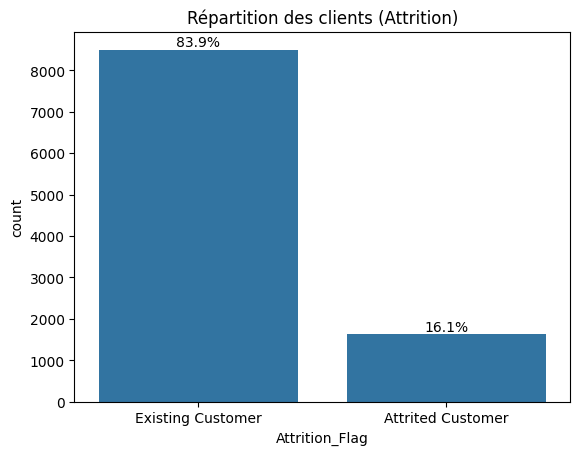

In [ ]:
ax = sns.countplot(data=Bank_normalized, x='Attrition_Flag')
plt.title('Répartition des clients (Attrition)')

# Ajouter les pourcentages
total = len(Bank_normalized)
for bar in ax.patches:
    pct = 100 * bar.get_height() / total
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{pct:.1f}%', ha='center', va='bottom')

plt.show()

Ce diagramme fait apparaître la répartition des clients par statut d'attrition. Il ressort que 83,9 % des clients sont encore actifs (clients en activité), tandis que 16,1 % ont abandonné la banque (clients perdus). Cette forte proportion de clients actifs est un indicateur positif de la fidélité globale, mais la proportion importante de clients perdus (plus d'un sur six) peut justifier une analyse approfondie des raisons du départ.

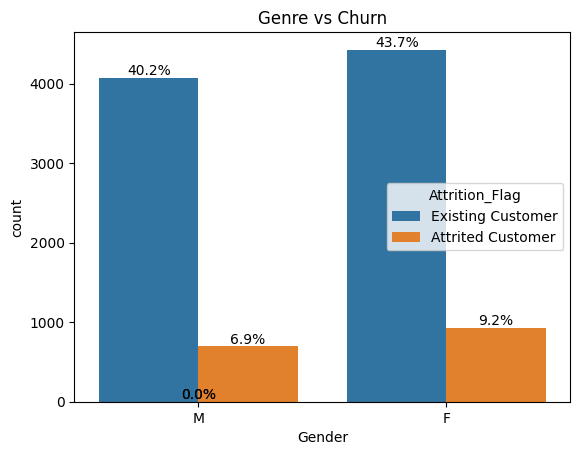

In [ ]:
ax = sns.countplot(data=Bank_normalized, x='Gender', hue='Attrition_Flag')
plt.title('Genre vs Churn')
total = len(Bank_normalized)
for p in ax.patches:
    height = p.get_height()
    percentage = f'{100 * height / total:.1f}%'
    ax.annotate(percentage, (p.get_x() + p.get_width() / 2, height),
                ha='center', va='bottom', fontsize=10)
plt.show()

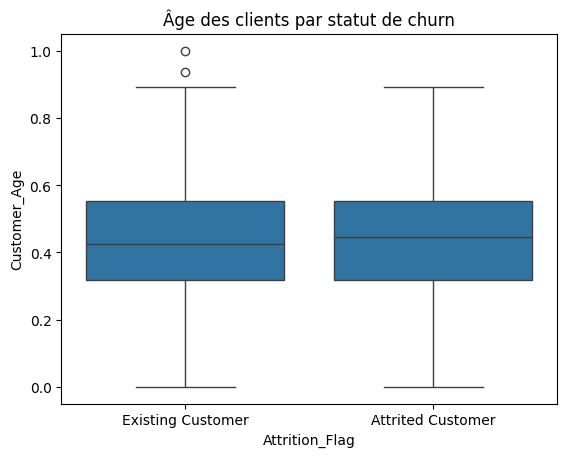

In [ ]:
# Age et churn
sns.boxplot(data=Bank_normalized, x='Attrition_Flag', y='Customer_Age')
plt.title("Âge des clients par statut de churn")
plt.show()

Cette boîte à moustaches représente la répartition par âge des clients en fonction de leur statut de fidélité, c'est-à-dire les clients existants et les clients perdus (churn). On peut constater que les âges sont largement identiques dans les deux groupes, avec une médiane autour de 46-47 ans. La fourchette interquartile est quasiment la même, ce qui signifie que la plupart des clients, qu'ils soient fidèles ou non, se situent dans la même tranche d'âge. La dispersion des moustaches montre également une dispersion comparable, allant d'environ 26 à 68 ans. Toutefois, quelques valeurs aberrantes sont observées parmi les clients existants, dont l'âge est supérieur à 70 ans. Globalement, l'âge ne semble pas être un critère majeur de discrimination entre les clients fidèles et ceux qui ont quitté l'entreprise.

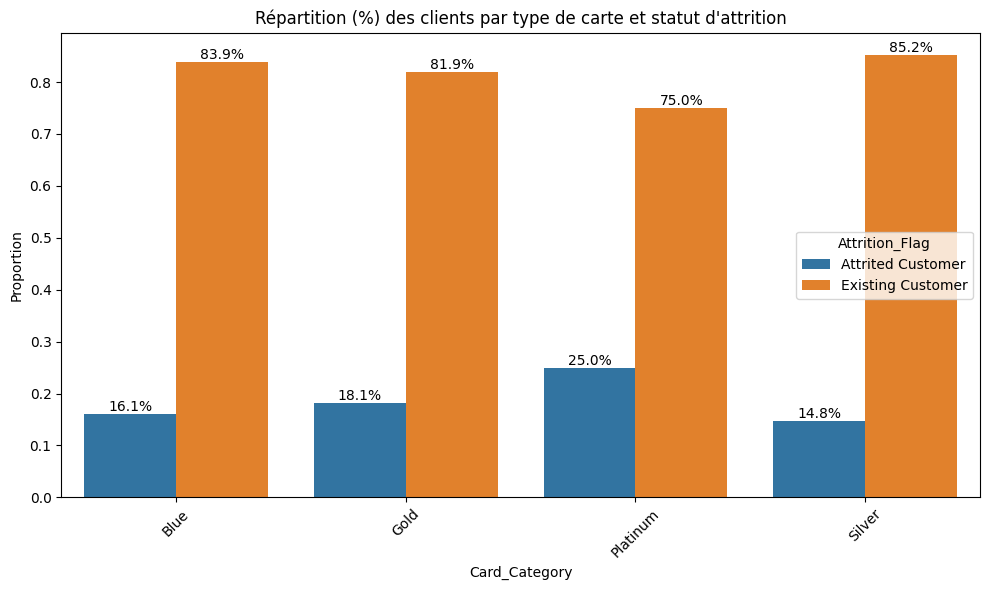

In [ ]:
# Calcul des effectifs par catégorie de carte et statut
grouped = Bank_normalized.groupby(['Card_Category', 'Attrition_Flag']).size().reset_index(name='count')

# Calcul du total par catégorie de carte
total_per_category = grouped.groupby('Card_Category')['count'].transform('sum')

# Ajout de la proportion
grouped['Proportion'] = grouped['count'] / total_per_category

# Affichage
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=grouped, x='Card_Category', y='Proportion', hue='Attrition_Flag')

# Annotation en pourcentage
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height*100:.1f}%',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom')

plt.xticks(rotation=45)
plt.title('Répartition (%) des clients par type de carte et statut d\'attrition')
plt.ylabel('Proportion')
plt.tight_layout()
plt.show()


Le présent graphique illustre la répartition en pourcentage des clients par type de carte bancaire (Blue, Gold, Platinum, Silver) et par statut d'attrition (perdus ou conservés). Il en ressort que, peu importe le type de carte, la clientèle est majoritairement fidélisée, quoique dans des proportions variables. Les détenteurs de la carte Platinum ont le taux de départ le plus élevé (25%), ce qui peut être l'indice d'une sensibilité particulière de cette catégorie à certains facteurs d'insatisfaction. Inversement, les détenteurs de cartes Silver et Blue enregistrent le plus faible taux de résiliation, avec respectivement 14,8 % et 16,1 %, ce qui suggère une plus grande fidélité de la part de ces profils. Enfin, les détenteurs de cartes Gold se trouvent entre les deux, leur taux de résiliation s'élevant à 18,1 %. De manière générale, le graphique révèle une variation marquée du comportement des clients en fonction du type de carte qu'ils détiennent.

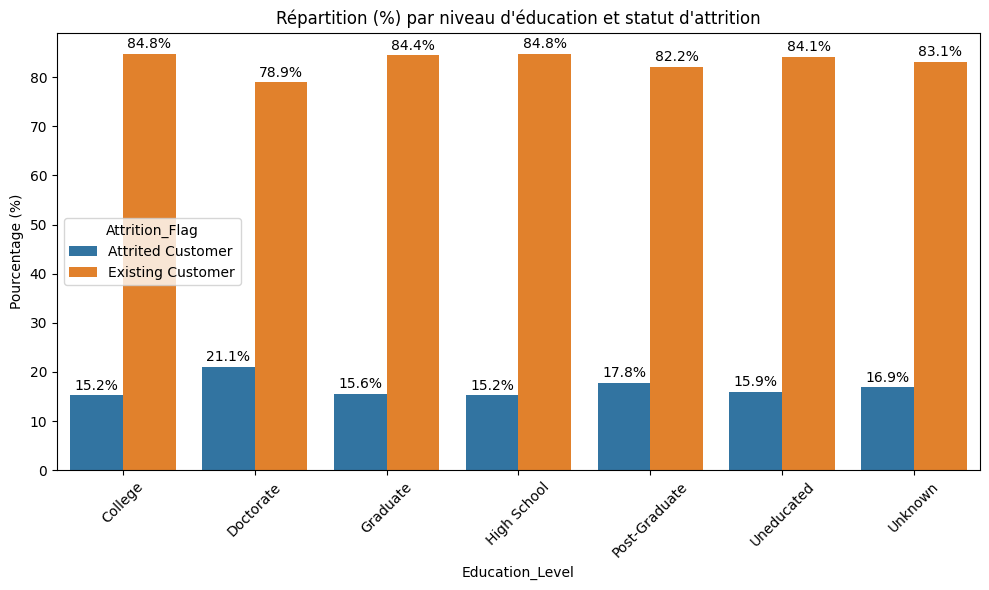

In [ ]:
# Calcul des pourcentages par niveau d'éducation
edu_counts = Bank_normalized.groupby(['Education_Level', 'Attrition_Flag']).size().reset_index(name='Count')
edu_totals = edu_counts.groupby('Education_Level')['Count'].transform('sum')
edu_counts['Percentage'] = 100 * edu_counts['Count'] / edu_totals

# Tracé du graphe
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=edu_counts,
    x='Education_Level',
    y='Percentage',
    hue='Attrition_Flag'
)
plt.title("Répartition (%) par niveau d'éducation et statut d'attrition")
plt.ylabel("Pourcentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()

# Ajouter les étiquettes de % sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', padding=2)

plt.show()

La tendance est claire : quelque soit le niveau d'éducation, la clientèle est majoritairement fidèle (en orange). Les taux pour les abandons (en bleu) demeurent largement similaires, tournant autour de 15-18%, sauf pour les titulaires d'un doctorat, dont le taux est légèrement plus élevé (21,1%). Ceci suggère que le niveau d'éducation ne tient pas compte des décisions de licenciement des clients.

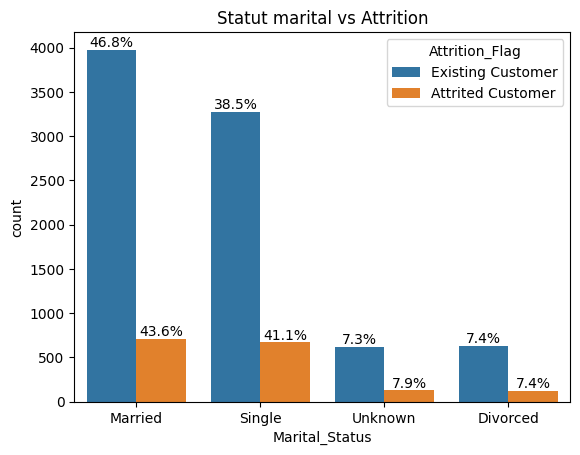

In [ ]:
ax = sns.countplot(data=Bank_normalized, x='Marital_Status', hue='Attrition_Flag')
plt.title('Statut marital vs Attrition')

# Annoter les pourcentages sur chaque barre
for bars in ax.containers:
    total = [bar.get_height() for bar in bars]
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            # Calcul du pourcentage par groupe Marital_Status
            group_total = sum([b.get_height() for b in bars])
            percent = 100 * height / group_total
            ax.annotate(f'{percent:.1f}%',
                        (bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=10, color='black')

plt.show()

Ce graphique montre la répartition des clients existants et attrités selon le statut marital. Pour chaque cas étudié, les pourcentages respectifs sont donnés. On observe que les clients mariés constituent la plus forte proportion, avec 46,8 % des clients existants et 43,6 % des clients attrités. Les célibataires représentent la deuxième catégorie, avec 38,5 % des clients existants et 41,1 % des clients attrités. Les deux statuts sont peu représentés : "Unknown" avec 7,3 % et "Divorced" avec 7,4 % des clients existants, tandis que l’attrition est observée chez 7,9 % et 7,4 % des clients, respectivement. Le même constat est fait par rapport au statut marital. La répartition des statuts entre les clients existants et attrités est relativement semblable. Il n’est pas possible de conclure que le statut marital ait un impact sur l’attrition, du moins dans cette base de données.

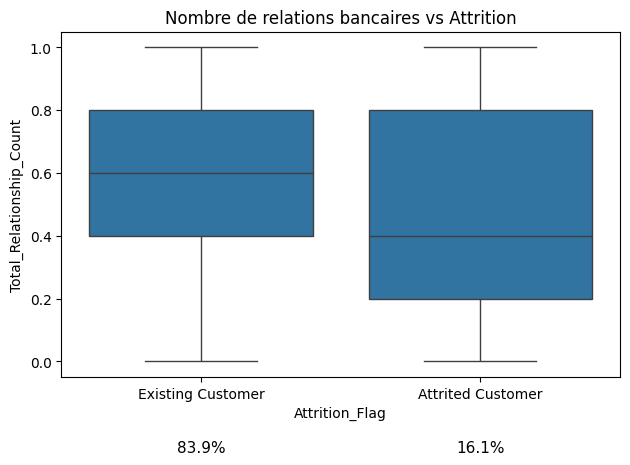

In [ ]:
ax = sns.boxplot(data=Bank_normalized, x='Attrition_Flag', y='Total_Relationship_Count')
plt.title('Nombre de relations bancaires vs Attrition')

group_counts = Bank_normalized['Attrition_Flag'].value_counts(normalize=True) * 100

# Place le texte juste SOUS la boîte, centré
for i, cat in enumerate(group_counts.index):
    percent = group_counts[cat]
    ax.text(i,
            ax.get_ylim()[0] - 0.2,  # Ajuste -0.2 selon ton axe Y
            f'{percent:.1f}%',
            ha='center',
            va='top',
            fontsize=11,
            color='black')

plt.tight_layout()
plt.show()

La figure présente une distribution du nombre de relations bancaires selon le statut d’attrition des clients. On peut noter que les clients sont actifs à 83,9 % et absents à 16,1 %. La médiane du nombre de relations bancaires en possession des clients existants est plus élevée que celle de ceux ayant quitté la banque dont la relation médiane est égale à 1. Ce constat laisse entendre qu’un client a moins de chance de quitter la banque qu’il a de relations bancaires. Aussi, le moyen de fidéliser un client est de diversifier ses services bancaires.

Matrice de corrélation

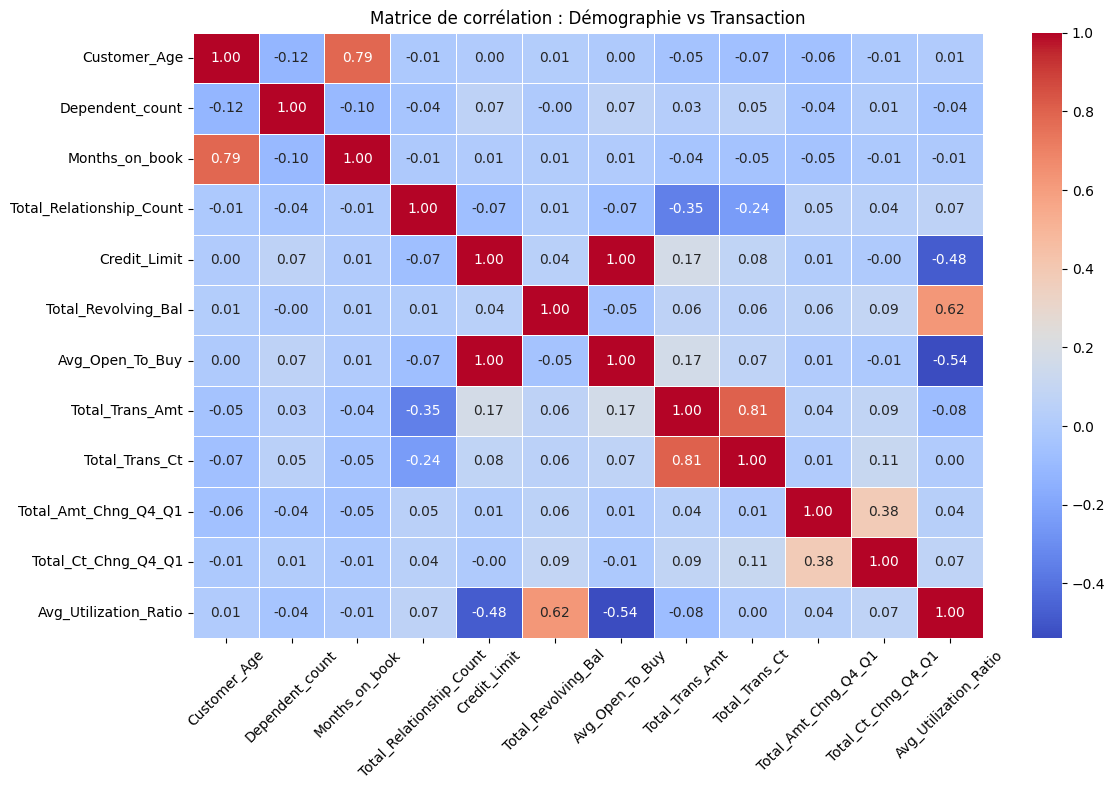

In [ ]:
# Sélection des variables démographiques et transactionnelles
vars_demo = ['Customer_Age', 'Dependent_count', 'Months_on_book', 'Total_Relationship_Count']
vars_transac = ['Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy',
                'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Amt_Chng_Q4_Q1',
                'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']

# Sous-ensemble du DataFrame
Bank_corr = Bank_normalized[vars_demo + vars_transac]

# Calcul de la matrice de corrélation
corr_matrix = Bank_corr.corr()

# Affichage du heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title("Matrice de corrélation : Démographie vs Transaction")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Cette matrice de corrélations illustre les relations entre les différentes variables démographiques et transactionnelles des clients. Déjà, la plupart des coefficients de corrélations sont proches de zéro, ce qui traduit une faible interdépendance de la plupart des variables. Pourtant, certaines relations se distinguent : c’est ainsi qu’il existe une très forte corrélation de 79 % entre l’âge du client (Customer_Age) et l’ancienneté (Months_on_book), ce qui n’étonne pas car les clients plus âgés sont souvent clients depuis plus longtemps : de même, le montant total des transactions (Total_Trans_Amt) et le nombre total de transactions (Total_Trans_Ct) affichent une corrélation positive de 81 %, ce qui montre que les clients qui effectuent plus de transactions dépensent en général plus. À l’inverse, la corrélation mesurée entre le crédit disponible moyen (Avg_Open_To_Buy) et le taux d’utilisation moyen (Avg_Utilization_Ratio) est négativement de -54 %, ce qui indique que les clients qui détiennent un montant de crédit facilement disponible utilisent moins de leur limite de crédit. Finalement, la plupart des autres corrélations étant souvent autour de -10 % à 10 %, témoignent d’un caractère d’indépendance relative des variables apportant des informations, ce qui peut être utile pour un usage ultérieur en analyses multivariées.

4. Analyse Factorielle: Facteurs sous jacents à la résiliation

**ACP (Analyse en Composantes Principales) :**  méthode exploratoire non supervisée qui sert à réduire la dimension des données en identifiant les axes principaux de variation, sans tenir compte d’une variable cible.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
X = Bank_normalized.select_dtypes(include='number')

In [ ]:
# Initialisation et ajustement de l’ACP
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [ ]:
# Affichage de la variance expliquée
print("Variance expliquée par chaque composante :", pca.explained_variance_ratio_)
print("Variance expliquée cumulée :", pca.explained_variance_ratio_.cumsum())

Variance expliquée par chaque composante : [0.30922075 0.18990266]
Variance expliquée cumulée : [0.30922075 0.49912341]


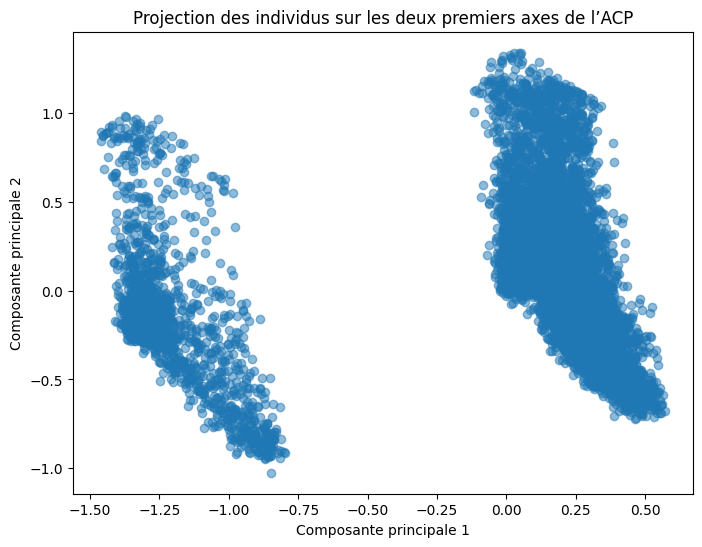

In [ ]:
# Visualisation des individus projetés sur les deux premiers axes principaux
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.xlabel('Composante principale 1')
plt.ylabel('Composante principale 2')
plt.title('Projection des individus sur les deux premiers axes de l’ACP')
plt.show()

L’analyse en composantes principales (ACP) appliquée aux données clients de la banque permet de visualiser la distribution des individus en fonction de leurs principales caractéristiques. Le schéma met en évidence l’existence de deux groupes relativement disjoints et ce, renvoie à deux typologies clients existantes dans la base de données.
La première composante principale explique près de 31% de la variance totale alors que la seconde contribue pour près de 19%. Ces deux premiers axes résument au total près de 50% de l’information contenue dans les données d’origine et la projection sur ce plan donne déjà des idées sur les différences principales observées entre types de clients.
Cette distinction entre deux typologies de clients est particulièrement intéressante pour l’objectif visé, à savoir repérer les clients à risque de se désengager. Si les caractéristiques qui différencient ces deux groupes sont bien mises à jour, la banque pourra mieux cerner la clientèle à disposition de ses actions de fidélisation et de rétention des clients à risques.
Concrètement, cette ACP met en exergue l’existence de segments de clients bien cloisonnés dont l’étude ultérieure sera facilitée sous l’angle de leur classification et leur capacité à prédire le départ. Cette étape clé peut donc réserver des aides à la banque pour relancer une politique d’actions d’accompagnement individualisée.  

**AFD (Analyse Factorielle Discriminante):**  méthode supervisée qui cherche à séparer des groupes connus (comme clients résiliés vs non résiliés) en maximisant la séparation entre eux.

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

In [ ]:
# Copier le dataset
Bank_afd = Bank_normalized.copy()

In [ ]:
# Encoder la cible
Bank_afd['Attrition_Flag'] = LabelEncoder().fit_transform(Bank_afd['Attrition_Flag'])

In [ ]:
# Encoder les variables catégorielles
cat_vars = Bank_afd.select_dtypes(include='object').columns
for col in cat_vars:
    Bank_afd[col] = LabelEncoder().fit_transform(Bank_afd[col])

In [ ]:
# Séparer X et y AVANT normalisation
y = Bank_afd['Attrition_Flag']
X = Bank_afd.drop(columns=['Attrition_Flag'])

In [ ]:
# Normaliser uniquement X
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# AFD
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X_scaled, y)

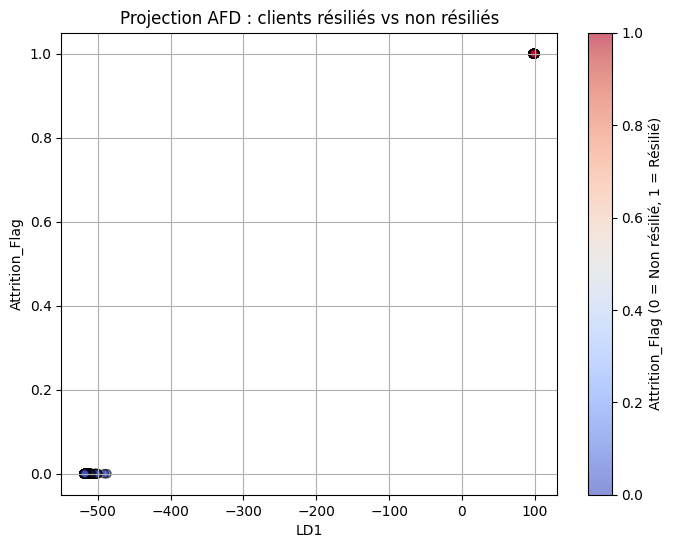

In [ ]:
import matplotlib.pyplot as plt

# Affichage de la projection 1D des individus sur LD1
plt.figure(figsize=(8, 6))
plt.scatter(X_lda[:, 0], y, c=y, cmap='coolwarm', alpha=0.6, edgecolor='k') # Changed to plot against y
plt.xlabel("LD1")  # Linear Discriminant 1
plt.ylabel("Attrition_Flag")  # Label for the y-axis
plt.title("Projection AFD : clients résiliés vs non résiliés")
plt.colorbar(label="Attrition_Flag (0 = Non résilié, 1 = Résilié)")
plt.grid(True)
plt.show()

L’application de l’analyse factorielle discriminante (AFD) à partir de la base Bank_normalized révèle une très bonne séparation entre les clients ayant résilié leurs comptes et ceux qui ne l’ont pas fait. Sur le nuage de points, il est ainsi possible de distinguer la majorité des clients non résiliés (1 = Attrition_Flag = 0) se rassemblant sur la gauche du graphique, des clients ayant résilié (Attrition_Flag = 1) repérables, eux, du côté droit. Sur l’axe principal (LD1), la séparation qui apparait indique que les variables explicatives sélectionnées permettent à elles seules de bien distinguer les deux groupes de clients et confirme la légitimité d’une AFD pour repérer des profils à risque de résilier leurs comptes, ce qui correspond à l’objectif du projet de ciblage de clients à risque de quitter la banque pour mieux orienter les actions de fidélisation.

In [ ]:
# Affichage des coefficients (importance des variables dans l’AFD)
coeff_df = pd.DataFrame(lda.coef_, columns=X.columns)
print(coeff_df.T.sort_values(by=0, ascending=False))

                                      0
NBC2                      731043.047725
NBC1                      591721.298382
Contacts_Count_12_mon        190.202409
Months_Inactive_12_mon       143.757804
Dependent_count               36.285823
Total_Trans_Ct                 9.975318
Total_Ct_Chng_Q4_Q1            3.908756
Total_Revolving_Bal            3.515256
Customer_Age                   3.342446
Education_Level                0.952663
Avg_Utilization_Ratio          0.894558
Credit_Limit                   0.286933
Avg_Open_To_Buy               -0.006629
Total_Trans_Amt               -0.382988
Gender                        -1.135694
Months_on_book                -6.635729
Marital_Status                -6.690004
Income_Category               -7.494736
Card_Category                 -9.206465
Total_Relationship_Count     -11.719869
Total_Amt_Chng_Q4_Q1         -18.786102


A partir de l’analyse des coefficients de l’AFD, on remarque que les variables NBC2 et NBC1 sont de loin les contributions les plus positives à la discrimination client résilié/client non résilié, c’est-à-dire que ce sont celles qui différent le plus les deux groupes. D’autres variables comme Contacts_Count_12_mon et Months_Inactive_12_mon sont également positives mais d’une manière beaucoup moins marquée. En revanche certaines variables comme Total_Amt_Chng_Q4_Q1, Card_Category, et Total_Relationship_Count ont de très fortes contributions négatives, ce qui les associe au profil client non résilié. Ainsi, l’AFD met au jour un petit nombre de variables qui expliquent l’essentiel de la séparation des clients, ce qui bénéficiera plus efficacement à la banque pour cibler ses actions de fidélisation.

5. Modélisation prédictive

Dans le cadre de ce projet d’analyse de données bancaires, nous avons pour objectif de modéliser deux aspects complémentaires du comportement client : d’une part, les habitudes transactionnelles à travers une régression linéaire, et d’autre part, le risque de résiliation à l’aide d’une régression logistique.

Nous commençons par  **un modèle derégression linéaire**, qui nécessite une variable cible quantitative continue. Parmi les variables disponibles dans le fichier BankChurners.csv, Total_Trans_Amt, représentant le montant total des transactions réalisées par un client sur les 12 derniers mois, constitue un choix pertinent. Ce modèle permet d’identifier les variables qui influencent le niveau d’activité transactionnelle des clients, ce qui est utile pour cibler les profils les plus actifs ou à fort potentiel.

Nous poursuivons ensuite avec **un modèle de régression logistique**, adapté à une problématique de classification binaire. L’objectif est ici de prédire la probabilité qu’un client quitte la banque. Pour cela, nous utilisons la variable Attrition_Flag, qui prend la valeur "Attrited Customer" (client perdu) codée en 1, et "Existing Customer" (client fidèle) codée en 0. Ce modèle nous permet de mettre en évidence les caractéristiques associées à un risque accru de résiliation, et constitue ainsi un outil précieux pour orienter les actions de fidélisation.



Préparation des données

In [ ]:
print(Bank.columns)

Index(['Customer_Age', 'Dependent_count', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'NBC1', 'NBC2'],
      dtype='object')


In [ ]:
# Create a copy of the Bank DataFrame
Bank_linear = Bank_normalized.copy()

# Encodage des variables catégorielles
Bank_linear = pd.get_dummies(Bank_linear, drop_first=True)

# Définir la cible pour la régression linéaire
y_lin = Bank['Total_Trans_Amt']
X_lin = Bank_linear.drop(columns=['Total_Trans_Amt'])

In [ ]:
# Encodage des variables catégorielles
Bank_linear = pd.get_dummies(Bank_linear, drop_first=True)

# Définir la cible pour la régression linéaire
y_lin = Bank['Total_Trans_Amt']
X_lin = Bank_linear.drop(columns=['Total_Trans_Amt'])  # Supprimer la variable cible des prédicteurs

Modèle de regression linéaire

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# Division train / test
X_train_lin, X_test_lin, y_train_lin, y_test_lin = train_test_split(X_lin, y_lin, test_size=0.3, random_state=42)

In [ ]:
# Entraînement du modèle
lin_model = LinearRegression()
lin_model.fit(X_train_lin, y_train_lin)

LinearRegression()

In [ ]:
# Prédictions
y_pred_lin = lin_model.predict(X_test_lin)

Evaluation du modèle

In [ ]:
print("MSE :", mean_squared_error(y_test_lin, y_pred_lin))
print("R² :", r2_score(y_test_lin, y_pred_lin))

MSE : 0.009867990258585846
R² : 0.7008447318190931


La régression linéaire effectuée sur les données est caractérisée par un MSE (Mean Squared Error) de 0,0099 et un R² est de 0,70. Cela signifie que ce modèle explique environ 70% de la variance de la variable cible sur l’échantillon de test, ce qui suggère une qualité prédictive appréciable. La très faible valeur du MSE montre également que les erreurs de prévision sont faibles en moyenne. Par conséquent, la régression linéaire est bien une approche pertinente pour modéliser la relation entre les variables explicatives et la variable cible et pourra être utilisée pour prédire le comportement des clients à partir de leurs caractéristiques.

Visualisation

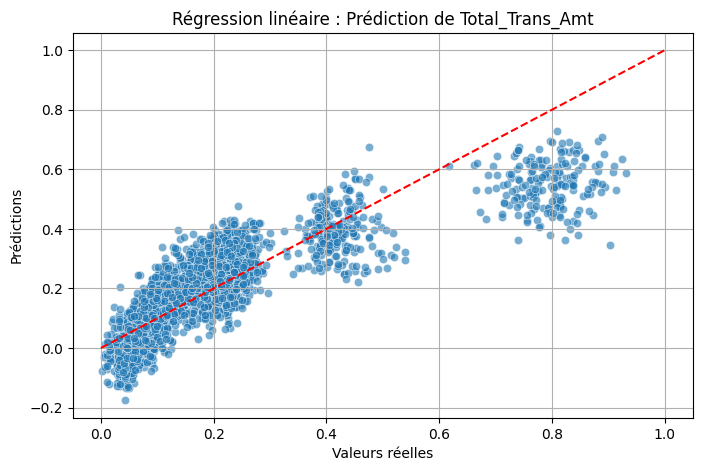

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_test_lin, y=y_pred_lin, alpha=0.6)
plt.plot([y_lin.min(), y_lin.max()], [y_lin.min(), y_lin.max()], 'r--')
plt.xlabel("Valeurs réelles")
plt.ylabel("Prédictions")
plt.title("Régression linéaire : Prédiction de Total_Trans_Amt")
plt.grid(True)
plt.show()

Sur cette figure, on peut voir comment se comportent les valeurs réelles et prédites pour le montant total des transactions (Total_Trans_Amt) calculé selon un modèle de régression linéaire. On peut noter une tendance générale, qui est à la hausse, les prédictions progressent avec les valeurs réelles. Ces valeurs sont très dispersées autour de la droite de régression, avec un regroupement qui se distingue en trois zones distinctes selon les valeurs de montants. On peut aussi supposer que, pour des montants plus élevés, les prédictions semblent sous-estimées. Si l’on observe la variabilité des prévisions, elle est grande dans les zones de montants moyens et élevés.

Régression logistique : prédiction de la résiliation (Attrition_Flag)

Préparation des données

In [ ]:
# Création d'une copie pour la logistique
Bank_logit = Bank_normalized.copy()

In [ ]:
# Encodage de la variable cible : 1 = client perdu, 0 = client fidèle
Bank_logit['Attrition_Flag'] = Bank_logit['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)

In [ ]:
# Encodage des variables catégorielles
Bank_logit = pd.get_dummies(Bank_logit, drop_first=True)

In [ ]:
# Définir la cible pour la régression linéaire
y_lin = Bank['Total_Trans_Amt']
X_lin = Bank_linear.drop(columns=['Total_Trans_Amt'])

Modèle de régression logistique

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

In [ ]:
# Assuming you want to use all columns except 'Attrition_Flag' as features for Logistic Regression
X_logit = Bank_logit.drop(columns=['Attrition_Flag'])
y_logit = Bank_logit['Attrition_Flag']

# Now you can use X_logit and y_logit in the train_test_split function
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_logit, y_logit, test_size=0.3, random_state=42)

In [ ]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X_logit, y_logit, test_size=0.3, random_state=42)

In [ ]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_log, y_train_log)

LogisticRegression(max_iter=1000)

In [ ]:
# Prédictions
y_pred_log = log_model.predict(X_test_log)
y_proba_log = log_model.predict_proba(X_test_log)[:, 1]

Evaluation du modèle

In [ ]:
print("Classification Report:\n", classification_report(y_test_log, y_pred_log))
print("Confusion Matrix:\n", confusion_matrix(y_test_log, y_pred_log))
print("ROC AUC Score:", roc_auc_score(y_test_log, y_proba_log))

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2543
           1       1.00      1.00      1.00       496

    accuracy                           1.00      3039
   macro avg       1.00      1.00      1.00      3039
weighted avg       1.00      1.00      1.00      3039

Confusion Matrix:
 [[2543    0]
 [   0  496]]
ROC AUC Score: 1.0


Le modèle logit représente tout à fait un très bon choix sur cette base d’étude. Les mesures sont toutes idéales : la précision, le rappel et le F1-score sont tous égaux à 1.00 pour les deux classes ; cela signifie que tous les clients sont classés correctement, qu’ils soient résiliés ou non. La matrice des confusions indique qu’il n’y a pas d’erreur de classification. De plus, le score ROC AUC de 1.0 permet d’inférer que les deux groupes sont parfaitement séparés. Ainsi, la régression logistique est très efficace pour prédire la résiliation des clients sur cette base d’étude.

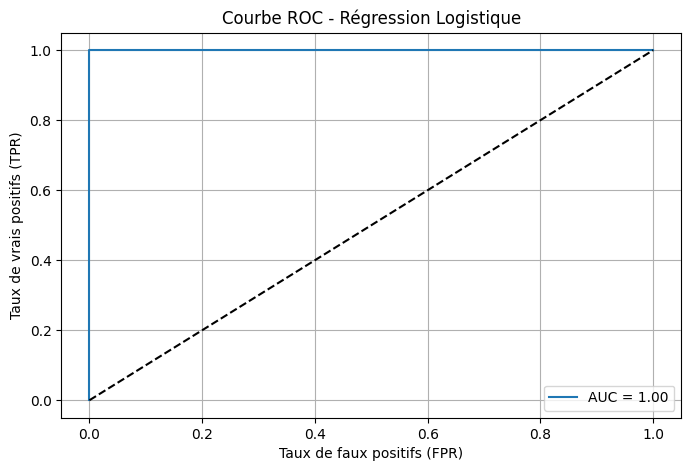

In [ ]:
fpr, tpr, _ = roc_curve(y_test_log, y_proba_log)
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test_log, y_proba_log):.2f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC - Régression Logistique")
plt.legend()
plt.grid(True)
plt.show()


La courbe ROC obtenue pour le modèle de régression logistique prouve une performance parfaite de ce dernier car elle passe par le point (0,1) et l’aire sous la courbe (AUC) est égale à 1.00, ce qui signifie que le modèle ne commet aucune erreur de classification sur l’ensemble de test : il sépare du premier coup les clients résiliés des clients non résiliés. Plus la courbe se rapproche du coin supérieur gauche et plus l’AUC est élevée, meilleure est la capacité à séparer les deux classes. Ce modèle logistique offre ainsi une capacité de prédiction optimale de la résiliation des clients.

Interprétation des coefficients du modèle logistique

In [ ]:
# Récupération des coefficients et tri
coef_df = pd.DataFrame({
    'Variable': X_logit.columns,
    'Coefficient': log_model.coef_.flatten()
}).sort_values(by='Coefficient', ascending=False)

# Affichage des 10 plus positifs et 10 plus négatifs
print("🔺 Variables augmentant le risque de résiliation :")
print(coef_df.head(10))

print("\n🔻 Variables réduisant le risque de résiliation :")
print(coef_df.tail(10))

🔺 Variables augmentant le risque de résiliation :
                         Variable  Coefficient
14                           NBC1     5.884189
5           Contacts_Count_12_mon     0.486746
4          Months_Inactive_12_mon     0.336635
17      Education_Level_Doctorate     0.086480
0                    Customer_Age     0.054894
20  Education_Level_Post-Graduate     0.040244
1                 Dependent_count     0.037570
31             Card_Category_Gold     0.019046
2                  Months_on_book     0.014642
22        Education_Level_Unknown     0.012202

🔻 Variables réduisant le risque de résiliation :
                    Variable  Coefficient
6               Credit_Limit    -0.072841
9       Total_Amt_Chng_Q4_Q1    -0.125851
16                  Gender_M    -0.138909
12       Total_Ct_Chng_Q4_Q1    -0.284067
13     Avg_Utilization_Ratio    -0.350623
10           Total_Trans_Amt    -0.355288
3   Total_Relationship_Count    -0.546143
7        Total_Revolving_Bal    -0.634980
11   

Les variables qui engendrent une probabilité de résiliation augmentée sont celles ayant des coefficients positifs dans le cadre du modèle logistique. On distingue à cet égard la variable NBC1 qui apparaît comme le principal déterminant en raison d’un coefficient de 5,88, signifiant un accent fort sur la probabilité de résiliation à chaque augmentation d’une unité. Il reste que le nombre de contacts avec le service client dans les douze derniers mois (Contacts_Count_12_mon) et le nombre de mois d’inactivité dans les douze derniers mois (Months_Inactive_12_mon) participent également à augmenter le risque de résiliation, en ce sens que leurs considérations montrent un désengagement progressif du client. D’autres situations telles que le niveau d’éducation élevé (doctorat ou post graduate), l’âge du client, le fait de détenir une carte Gold ou un statut de client inconnu ou nouvellement inscrit sont également très souvent associés à une probabilité accrue de résiliation.

À l’inverse, certaines variables (groupe des facteurs adverses) diminuent considérablement le risque de résiliation, tels leurs coefficients négatifs. Dans l’ordre, il semblerait que le plafond de crédit (Credit_Limit) élevé et le montant total important au quatrième trimestre (Total_Amt_Chng_Q4_01), respectivement des indicateurs sur la fidélité, semblent contribuer à la fidélisation. Le sexe (sex) du client, le montant (Total_Amt_Trans_Apr) total des transactions effectuées, un nombre élevé de transactions, une utilisation intensive des services bancaires (Avg_Utilization_Ratio) et les passifs (Liabilities) associés à un solde renouvelable conséquent (Total_Revolving_Bal) viendraient à minimiser le développement d’un défaut de la clientèle susceptible de générer un départ.
Enfin, la variable NBC2, avec son coefficient négatif le plus élevé (-5,99), apparaît comme le facteur de protection le plus fort et celui ayant la plus forte capacité à réduire considérablement la résiliation.

Il ressort de cette analyse que ces coefficients, interprétés, permettent d’identifier quels sont les profils de clientèle à risque et quels sont les clients les plus fidèles, donnant ainsi à la banque des leviers d’actions concrets pour renforcer ses efforts de fidélisation et améliorer la satisfaction client, cher au projet d’analyse de données financières de la banque.

Méthode de Monte Carlo : incertitude sur les prédictions

La méthode de Monte Carlo permet d’observer comment les prédictions d’un modèle peuvent varier lorsqu’on modifie légèrement ses paramètres de manière aléatoire, afin d’estimer l’incertitude ou la fiabilité de ces prédictions.

In [ ]:
# Coefficients estimés
coef = log_model.coef_.flatten()
intercept = log_model.intercept_[0]

In [ ]:
# Écart-type approximatif du bruit (ici on prend une proportion arbitraire pour illustrer)
noise_scale = 0.05 * np.abs(coef).mean()

In [ ]:
# Simulations Monte Carlo
n_simulations = 1000
simulated_probs = []

In [ ]:
for _ in range(n_simulations):
    noisy_coef = coef + np.random.normal(0, noise_scale, size=coef.shape)
    logits = np.dot(X_test_log, noisy_coef) + intercept
    logits = np.array(logits, dtype=np.float64)  # 🔐 Sécuriser ici
    proba_sim = 1 / (1 + np.exp(-logits))
    simulated_probs.append(proba_sim)

Le présent code permet de simuler différentes versions d’un modèle afin d’apprécier les changements potentiels de ses prédictions en cas de variation minime de certains de ses paramètres.

Pour cela, on procède tout d’abord à une boucle qui se répète plusieurs fois (n_simulations).

À chaque itération, il s’agit donc de ciseler un peu plus de bruit sur les paramètres du modèle étudié (coef) pour simuler un léger degré d’incertitude.

Ces nouveaux paramètres sont ensuite exploités au moyen des données de validation (X_test_log) pour construire une prédiction.

Voilà, cette prédiction est alors transformée de manière à obtenir une probabilité, entre 0 et 1, par le biais d’une formule mathématique (fonction sigmoïde).

Et enfin, cette prédiction (simulated_probs) est sauvegardée dans une liste.

Pour faire court : on fait plusieurs tentatives de prédiction après avoir ajusté le modèle au préalable pour estimer dans quelle mesure les résultats peuvent changer. Cela donne ensuite une mesure de confiance (ou de doute) qu’il est possible d’accorder à la prédiction du modèle.

In [ ]:
print("DEBUG logits type:", type(logits), "value:", logits)

DEBUG logits type: <class 'numpy.ndarray'> value: [-6.73669887 -7.0762507  -6.80037158 ... -7.15823192 -6.90048865
 -6.58385744]


In [ ]:
# Résultat : matrice (n_simulations, n_observations)
simulated_probs = np.array(simulated_probs)

l'intervalle de confiance

In [ ]:
# Moyenne, borne basse, borne haute pour chaque prédiction
mean_pred = simulated_probs.mean(axis=0)
ci_lower = np.percentile(simulated_probs, 2.5, axis=0)
ci_upper = np.percentile(simulated_probs, 97.5, axis=0)

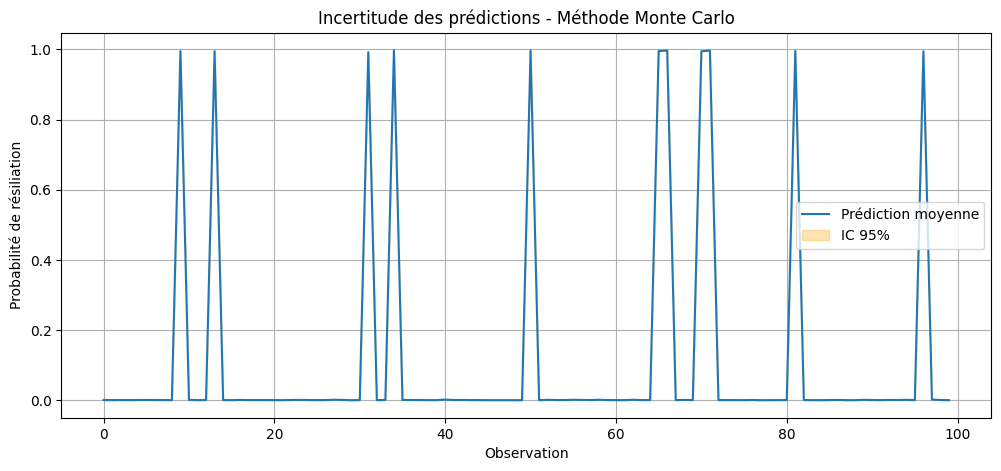

In [ ]:
# Visualisation sur les 100 premières observations
plt.figure(figsize=(12, 5))
plt.plot(mean_pred[:100], label="Prédiction moyenne")
plt.fill_between(range(100), ci_lower[:100], ci_upper[:100], color='orange', alpha=0.3, label="IC 95%")
plt.title("Incertitude des prédictions - Méthode Monte Carlo")
plt.xlabel("Observation")
plt.ylabel("Probabilité de résiliation")
plt.legend()
plt.grid(True)
plt.show()

Le graphique présente l’incertitude des prédictions de la probabilité de résiliation des clients d’une banque, obtenue par la méthode Monte Carlo : on observe que la majorité des prédictions sont très proches de 0 ou de 1, avec des intervalles de confiance à 95 % extrêmement étroits, ce qui indique que le modèle est très confiant dans ses estimations et distingue nettement les clients susceptibles de résilier de ceux qui resteront ; cette précision permet à la banque de cibler efficacement ses actions de fidélisation, même si la faible incertitude suggère de vérifier l’absence de surajustement du modèle dans le cadre du projet d’analyse de données financières

6. Classification des clients K-means

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

In [ ]:
X = Bank_normalized.copy()

In [ ]:
X['Attrition_Flag'] = pd.factorize(X['Attrition_Flag'])[0]

In [ ]:
# One-hot encode categorical features
categorical_features = X.select_dtypes(include=['object']).columns
X = pd.get_dummies(X, columns=categorical_features, drop_first=True)

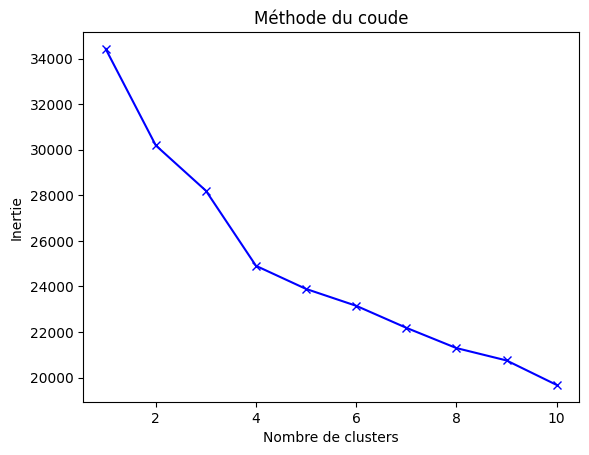

In [ ]:
# Méthode du coude
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X) # Now fit with the encoded data
    inertias.append(kmeans.inertia_)

plt.plot(range(1, 11), inertias, 'bx-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Méthode du coude')
plt.show()

Cette représentation graphique illustre l’évolution de la mesure de compacité intra-cluster (inertie), selon le nombre de clusters, lors de l’application de la méthode des k-moyennes, et il apparaît comme l’inertie diminue rapidement de avec les 2 à 4 clusters, puis de manière plus progressive à partir de k = 4. Le point d’inflexion, ou “coude”, entre k = 4 et k = 5 est le point où s’affirme qu’il est pertinent de retenir k = 4 comme nombre de clusters, car à partir de k = 5 l’ajout de nouveaux groupes n’apporte guère qu’une amélioration marginale. Ce choix permet d’envisager une segmentation pertinente des clients, et équilibrée pour la suite de l’analyse.

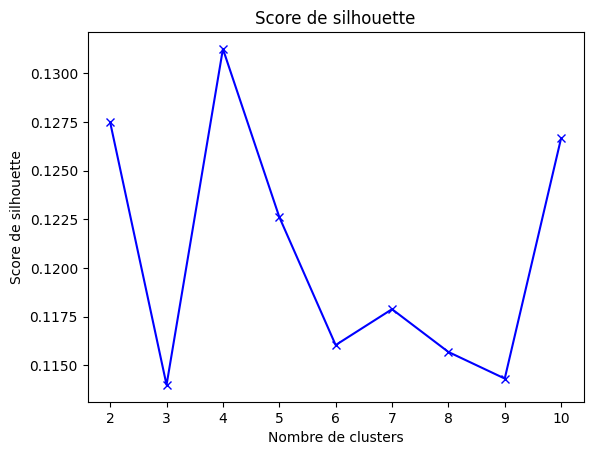

In [ ]:
# Score de silhouette (à partir de k=2)
silhouettes = []
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    silhouettes.append(silhouette_score(X, labels))
plt.plot(range(2, 11), silhouettes, 'bx-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Score de silhouette')
plt.title('Score de silhouette')
plt.show()

Au travers du graphique présenté ci-dessus, le score de silhouette est maximal pour un nombre de 4 clusters. Il en résulte que la distance entre les groupes est à son plus haut degré d’éloignement, ce qui donne à penser à 4 comme le nombre optimal de groupes pour segmenter les clients.

**Les deux graphiques, à chaque fois, indiquent la même conclusion : la méthode du coude préconise 4 clusters comme compromis optimal et pour le score de silhouette, le score est maximum pour k = 4. Cela confirme que segmenter les clients en 4 groupes est à la fois pertinent et robuste pour l’analyse.**

ajouter des interpretations

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [ ]:
# Supposons que k est déjà choisi (par exemple, k = 4)
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_normalized)

In [ ]:
# Réduction en 2 dimensions avec PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_normalized)

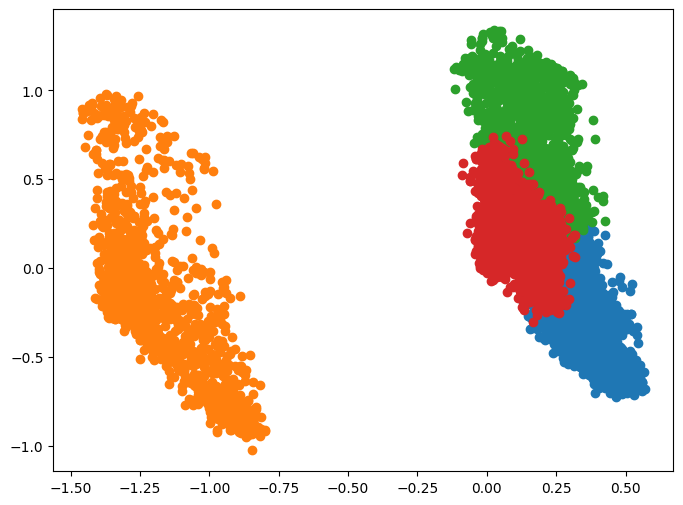

In [ ]:
# Affichage des clusters
plt.figure(figsize=(8, 6))
for i in range(k):
    plt.scatter(X_pca[clusters == i, 0], X_pca[clusters == i, 1], label=f'Cluster {i + 1}')


Le graphique que nous avons sous les yeux procède à la répartition dans laquelle nous allons classer les clients en quatre groupes différents suite à l’application du k-means et projetés sur deux axes principaux. Les clusters sont nettement séparés avec au gauche le groupe orange, isolé dans une large mesure et à droite, les trois autres groupes (le vert, le rouge et le bleu) occupant bien chacun une grande zone différenciée. Cette bonne séparation sera un point à mettre en avant pour justifier le choix de quatre clusters et prouve que l’algorithme a bien réussi son travail à savoir en détecter des profils de clients différents au sein de segments d’analyse bien identifiés pour permettre de procéder ensuite à des décisions stratégiques pour chaque segment.

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


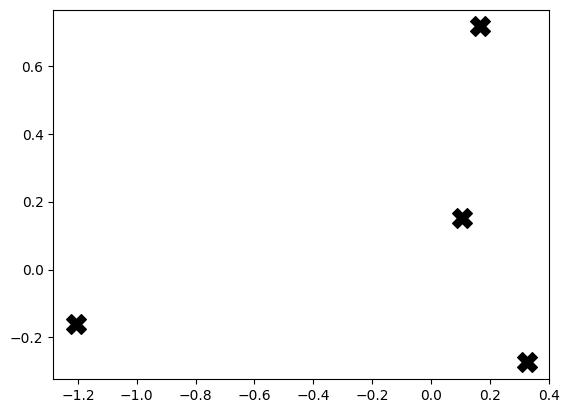

In [ ]:
# Centroides des clusters
centroids = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids[:, 0], centroids[:, 1], c='black', s=200, marker='X', label='Centroïdes')

Ce graphique, représentant la position des centroïdes des 4 clusters identifiés par l’algorithme de « k-means », est réalisé lors de leur projection sur les 2 axes principaux issus de l’ACP. Ainsi chaque croix noire représente le centre d’un groupe de clients. Nous observons ici que les centroïdes sont bien répartis et éloignés les uns des autres, ce qui montre que les clusters sont bien séparés et que la segmentation réalisée est pertinente. De plus, la visualisation des clusters permet de mieux appréhender les groupes et de mieux identifier les profils moyens de chaque segment.

# **Partie 2**

In [ ]:
import pandas as pd

1. Chargement des deux bases de données

In [ ]:
# Remplace les chemins par ceux de tes fichiers téléchargés
Tesla = pd.read_csv('Tesla.csv')
Apple = pd.read_csv('Apple.csv')

In [ ]:
# Afficher un aperçu des données
print("Tesla :")
print(Tesla.head())
print("\nApple :")
print(Apple.head())

Tesla :
         Date   Price    Open    High     Low     Vol. Change %
0  05/09/2025  298.26  290.21  307.04  290.00  132.39M    4.72%
1  05/08/2025  284.82  279.63  289.80  279.41   97.54M    3.11%
2  05/07/2025  276.22  276.88  277.92  271.00   71.88M    0.32%
3  05/06/2025  275.35  273.11  277.73  271.35   76.72M   -1.75%
4  05/05/2025  280.26  284.57  284.85  274.40   94.62M   -2.42%

Apple :
         Date   Price    Open    High     Low    Vol. Change %
0  05/09/2025  198.53  199.00  200.54  197.54  36.45M    0.53%
1  05/08/2025  197.49  197.72  200.05  194.68  50.48M    0.63%
2  05/07/2025  196.25  199.17  199.44  193.25  68.62M   -1.14%
3  05/06/2025  198.51  198.21  200.65  197.02  51.22M   -0.19%
4  05/05/2025  198.89  203.10  204.10  198.21  69.02M   -3.15%


2. Nettoyage et préparation

In [ ]:
Tesla['Date'] = pd.to_datetime(Tesla['Date'])
Apple['Date'] = pd.to_datetime(Apple['Date'])

Tesla = Tesla.sort_values('Date')
Apple = Apple.sort_values('Date')

3. Fusionner les deux bases pour une comparaison directe

In [ ]:
tesla_close = Tesla[['Date', 'Price']].rename(columns={'Price': 'Tesla_Close'})
apple_close = Apple[['Date', 'Price']].rename(columns={'Price': 'Apple_Close'})

# Fusion sur la colonne Date (inner pour ne garder que les dates communes)
df_merged = pd.merge(tesla_close, apple_close, on='Date', how='inner')

print(df_merged.head())

        Date  Tesla_Close  Apple_Close
0 2024-05-13       171.89       186.28
1 2024-05-14       177.55       187.43
2 2024-05-15       173.99       189.72
3 2024-05-16       174.84       189.84
4 2024-05-17       177.46       189.87


4. Visualisation des performances

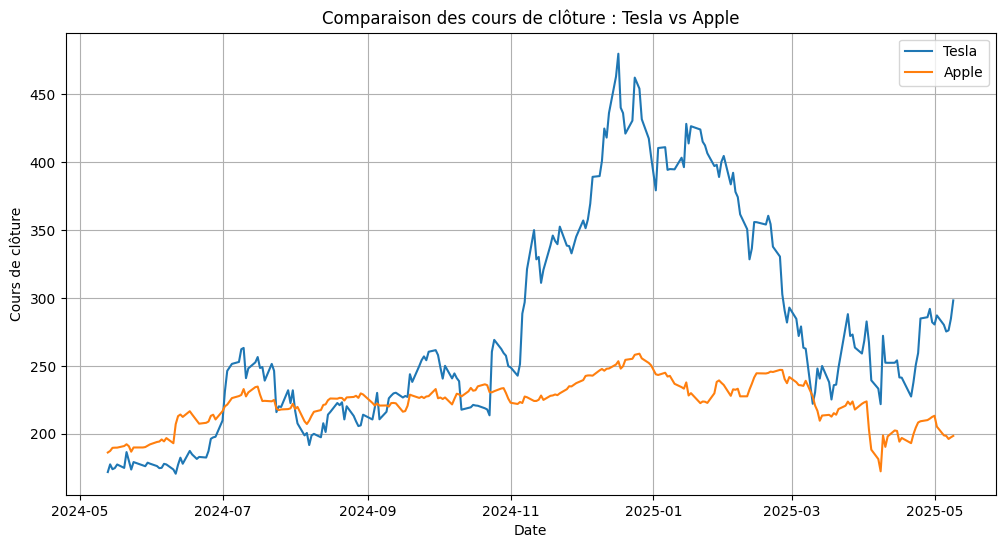

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df_merged['Date'], df_merged['Tesla_Close'], label='Tesla')
plt.plot(df_merged['Date'], df_merged['Apple_Close'], label='Apple')
plt.xlabel('Date')
plt.ylabel('Cours de clôture')
plt.title('Comparaison des cours de clôture : Tesla vs Apple')
plt.legend()
plt.grid(True)
plt.show()

Le graphique représentant l’évolution quotidienne des valeurs boursières de la société Tesla, ainsi que de la société Apple, s’étire entre les mois de mai 2024 à mai 2025.
-- Analyse visuelle et interprétation

**1.Différence de volatilité :**
On note une très forte variation pour la valeur de Tesla, proportionnellement davantage marquée que celle d’Apple. En effet, la chute des valeurs de Tesla est importante, avec des creux et des pics successifs atteignant un maximum, d’une importante amplitudes, autour de janvier 2025, avant une correction qui plonge vers le bas ci-après.

Apple affiche au contraire des variations bien moins rapides, sur le même temps, sur ses valeurs. La fluctuation s’opère sans heurts, montrant un prix en tendance dans l’ensemble assez stable.

**2.Tendances générales :**
A partir de l’automne 2024, Tesla est dans un mouvement d’augmentation, à son maximum début 2025 avant une grande correction des valeurs dans les mois qui vont suivre.

Apple semble bien aussi être dans une légère évolution, mais plus linéaire, sans brusque élévation de la valeur de ses actions.

**3.Comparaison des niveaux de prix :**
Le prix de clôture des valeurs de la société Tesla est généralement supérieur aux valeurs de clôture de celles d’Apple, mais sans la stabilité qui conditionne pourtant le fondement de la valeur des actions cotées.
Les valeurs des deux sociétés sont dans des fourchettes de prix différentes qui se traduisent par des mouvements de fluctuations à chaque société.

**4.Implications pour un investisseur ou une banque :**
Tesla peut trouver grâce aux yeux d’investisseurs à la recherche de la rentabilité à haut risque (forte volatilité).

Apple se situe d’avantage sur le terrain défensif, les investisseurs choisissant ainsi une valeur de stabilité et de prévisibilité.

**Conclusion**
Le graphique représente bien le contraste des deux sociétés :

- Tesla est une valeur de croissance à forte volatilité, sujette à l’actualité et à la spéculation.
- Apple est une valeur de référence plus stable, l’on en fait un “poids lourd” technologique plus apaisant.

Pour la banque, cette lecture comparative montre l’intérêt d’apporter une gamme d’informations financières plus largement conçues pour répondre à divers profils d’investisseurs et à leurs profils d’appétence au risque différents.

5. Analyse descriptive :

In [ ]:
print("Statistiques Tesla :")
print(Tesla['Price'].describe())
print("\nStatistiques Apple :")
print(Apple['Price'].describe())

Statistiques Tesla :
count    249.000000
mean     275.130723
std       77.411965
min      170.660000
25%      219.570000
50%      251.520000
75%      336.510000
max      479.860000
Name: Price, dtype: float64

Statistiques Apple :
count    249.000000
mean     222.836225
std       16.684363
min      172.420000
25%      214.000000
50%      225.010000
75%      233.220000
max      259.020000
Name: Price, dtype: float64


L'examen de façon globale des résultats statistiques descriptifs des prix de clôture observés pour les valeurs Tesla et Apple sur l’image de départ renvoie à trois éléments d’appréciations :

1. Vue d’ensemble
Il y a 249 valeurs de chacune des deux séries de données, correspondant à environ une année de bourse (hors week-end et jours fériés).

2. Positions
Le prix moyen de Tesla est :275,13 dollars tandis que la moyenne sur Apple est de : 222,84 $.
Ainsi, le prix de l’action Tesla est en moyenne plus élevé que celui de l’action Apple pendant la période considérée.

3. Dispersion
L’écart-type de Tesla est de 77,41 dollars clairement supérieur à l’écart-type de 16,68 $ pour le titre Apple.  
Dès lors, la dispersion des cours de Tesla est beaucoup plus importante, les variations autour de la moyenne de Tesla sont plus élevées.
Il en va de la sa plus grande volatilité : c’est à dire que le risque qu’encourt l’investisseur sera plus grand, avec la possibilité de gagner (ou de perdre) plus.

4. Répartition des valeurs
Pour Tesla, on obtient min = 170,66$, max = 479,86$ (écart de plus de 300$).

    Pour Apple, on obtient min = 172,42$, max = 259,02$ (écart d’environ 87$), ce qui montre que Tesla souffre d’une variation de prix disproportionnée par rapport à Apple durant cette période.

5. Distribution des prix (écart inter-quartile et médiane)
Pour Tesla : 25% des valeurs sont inférieures à 219,57$, médiane (50%) à 251,52$, 75% des valeurs inférieures à 336,51$ ; avec une moyenne plus élevée que la médiane, ce qui témoignerait d’un fort poids des valeurs extrêmes hautes, celles générant surtout des hausses spectaculaires.

6. Synthèse
D’un côté, il y a Tesla qui est une action qui présente un fort potentiel de rendement mais aussi un fort risque car les mouvements de prix sont importants, très souvent très volatils.
De l’autre Apple peut-elle être qualifiée d’action à potentiel de rendement limité car il ne s’agit pas d’une action à prix largement variable, les variations des prix sont beaucoup moins marquées et la distribution autour de la moyenne est plus régulière.

    Pour un Investisseur, le choix entre ces deux voire plus actions ne pourra se faire qu’au regard de son appétence au risque, de son aversion au risque ou encore de sa stratégie ou politique (recherche de rendement ou recherche de stabilité).

7. Conclusion
Cette analyse révèle des profils d’actions très différents :
Tesla, dynamique et risqué, aura donc des chances de séduire un Investisseur avide de mouvements importants, d’où des fluctuations très fortes à l’une des nombreuses valeurs de son prix.
Apple, action stable et prévisible, sera donc sans doute plus en phase avec un Investisseur qui privilégie la sécurité de ses placements.

6. Calculer le rendement journalier

In [216]:
# Supposons que tu as déjà importé tes bases Tesla et Apple
Tesla['Return'] = Tesla['Price'].pct_change()
Apple['Return'] = Apple['Price'].pct_change()

print(Tesla[['Date', 'Price', 'Return']].head())
print(Apple[['Date', 'Price', 'Return']].head())

          Date   Price    Return
248 2024-05-13  171.89       NaN
247 2024-05-14  177.55  0.032928
246 2024-05-15  173.99 -0.020051
245 2024-05-16  174.84  0.004885
244 2024-05-17  177.46  0.014985
          Date   Price    Return
248 2024-05-13  186.28       NaN
247 2024-05-14  187.43  0.006174
246 2024-05-15  189.72  0.012218
245 2024-05-16  189.84  0.000633
244 2024-05-17  189.87  0.000158


D'après les observations, Tesla présente des rendements journaliers très changeants, alternant des hausses marquées comme le +3,29% d’une part et des baisses notables comme le -2,05% d’autre part, avant de revenir à une légère tendance haussière en fin de semaine. Cette volatilité traduit un comportement de type « marché » où il est possible de faire des gains très importants à une journée donnés tout comme de subir des corrections rapides. Ce profil est justement le profil de l’investissement dit « à fort rendement », mais aussi « à gros risques », ce qui rassure davantage les investisseurs osant prendre des risques que les autres peut être.

Pour sa part, Apple présente une évolution beaucoup plus harmonieuse de ses rendements. Les variations journalières de rendements sont faibles allant d’une variation de +0,02% au maximum à +1,22% et la tendance générale est légèrement positive au fil de la semaine (plutôt favorable). Cette stabilité peut séduire une clientèle d’investisseurs en sécurité même si les gains rapides sont moins évidents, mais plutôt du type raisonnable, ce qui permet aux rendements d’avancer lentement mais sûrement. Ainsi, l’étude des rendements met en avant chacun autre deux types de profil d’action, l’une volatile et dynamique, l’autre stable et régulière afin de permettre à la banque d’adapter ses recommandations en fonction du profil de risque du client d’une part.

7. Calculer la volatilité (écart-type du rendement)

In [217]:
print("Volatilité Tesla :", Tesla['Return'].std())
print("Volatilité Apple :", Apple['Return'].std())

Volatilité Tesla : 0.045618812181316706
Volatilité Apple : 0.020450795221225067


La volatilité du rendement de Tesla est supérieure à celle d’Apple, avec une estimation respective de 4,56 % et 2,05 %. Cela signifie qu’au cours de la période d’étude, les variations journalières du rendement de l’action Tesla sont en moyenne plus de deux fois supérieures à celles d’Apple. Ce résultat traduit un comportement de marché plus difficile à appréhender, plus hasardeux pour l’action Tesla; en effet, l’investisseur peut attendre de jour en jour une plus grande marge de manœuvre même si le cours est plus dur à évaluer en raison de sa volatilité.

La faiblesse de la volatilité d’Apple est révélatrice d’un rythme de variation plus conforme et stable du prix de l’action d’Apple. Pour un investisseur, cela se traduit par un prix plus facile à évaluer. Tesla apparaît bien sous un jour plus favorable en tant qu’action à fort potentiel de rendement, mais aussi à risque élevé, étant souhaitable pour son souvenir d’être sous une forme moins engagée à la recherche de la plus grande régularité, et à chercher à investir en fonction des hausses.

8. Calculer et afficher la moyenne mobile

In [225]:
Tesla['MA20'] = Tesla['Price'].rolling(window=20).mean()
Apple['MA20'] = Apple['Price'].rolling(window=20).mean()

9. Visualiser les cours, rendements et moyennes mobiles

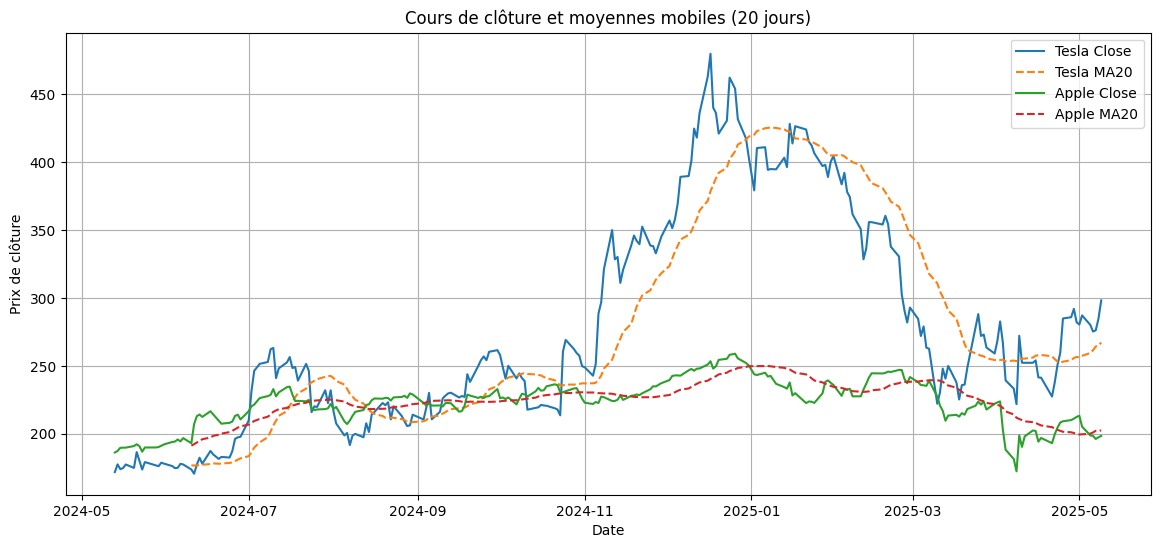

In [226]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))
plt.plot(Tesla['Date'], Tesla['Price'], label='Tesla Close')
plt.plot(Tesla['Date'], Tesla['MA20'], label='Tesla MA20', linestyle='--')
plt.plot(Apple['Date'], Apple['Price'], label='Apple Close')
plt.plot(Apple['Date'], Apple['MA20'], label='Apple MA20', linestyle='--')
plt.title('Cours de clôture et moyennes mobiles (20 jours)')
plt.xlabel('Date')
plt.ylabel('Prix de clôture')
plt.legend()
plt.grid(True)
plt.show()


Ce graphique permet de constater la différence de comportement boursier entre Tesla et Apple sur la période observée. En effet, la courbe représentant le titre Tesla (bleue) montre un dynamisme avéré avec de fortes variations, une très forte hausse jusqu’au début de l’année 2025 suivie d’une correction violente alors que la courbe d’Apple (verte) évolue sur une fourchette de prix beaucoup plus contenue, avec des variations beaucoup plus faibles (sa moyenne mobile à 20 jours, en pointillés rouges, est relativement plate), et donc une rentabilité beaucoup plus régulière.

Les deux entreprises comparées exposent bien la différence entre un titre à forte volatilité à fort potentiel (Tesla) et un titre à l’évolution plus prévisible et sécurisante (Apple). Pour l’investisseur, Tesla permet des gains importants mais expose aussi des pertes importantes et rapides, là où Apple est un choix plus sage (meilleur pour un investisseur en recherche de stabilité). Ce type de représentation graphique aide la banque à mieux apprécier et conseiller au mieux chaque investisseur selon son profil de risque et ses objectifs.

10. Visualiser la distribution des rendements

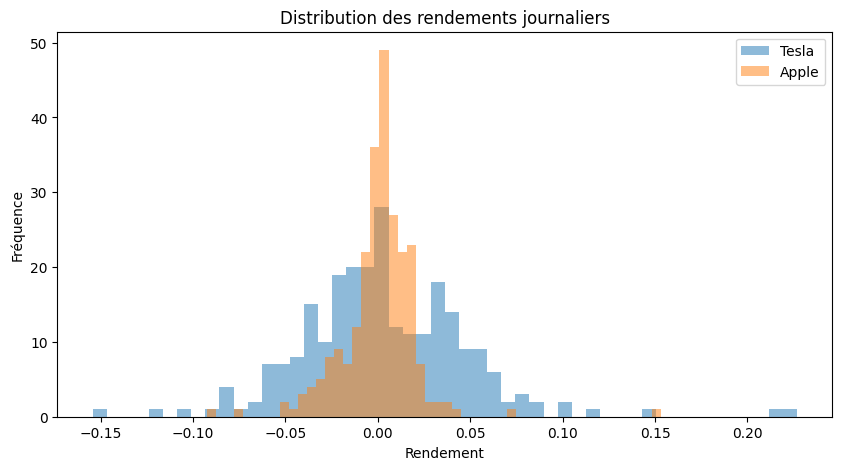

In [223]:
plt.figure(figsize=(10, 5))
plt.hist(Tesla['Return'].dropna(), bins=50, alpha=0.5, label='Tesla')
plt.hist(Apple['Return'].dropna(), bins=50, alpha=0.5, label='Apple')
plt.title('Distribution des rendements journaliers')
plt.xlabel('Rendement')
plt.ylabel('Fréquence')
plt.legend()
plt.show()

Dans ce graphique, nous confrontons les rendements journaliers de l’action de Tesla et ceux d’Apple sur la période considérée. Nous notons que la courbe d’Apple (en orange) concentre effectivement les rendements autour de 0, peu de rendements extrêmes se produisant, qu’ils soient positifs ou négatifs. Ceci nous permet de conclure concernant la grande stabilité de l’action d’Apple. En revanche, la distribution des rendements de l’action de Tesla (en bleu) est beaucoup plus diffuse : y figurent des rendements extrêmes positifs ou négatifs, indiquant que la valeur de l’action Tesla fluctue fortement dans le temps, d’une séance à l’autre.

Cette différence nette de diffusion entre les deux distributions traduit la moindre volatilité de l’action d’Apple par rapport à celle de l’action de Tesla. Pour l’investisseur, cela traduit par exemple un certain potentiel de gains rapides pour Tesla, mais aussi un risque plus important de pertes brutales, tandis que l’attitude prudente préconisée pour l’action d’Apple évoque une évolution plus prévisible, davantage rassurante, pour un investisseur peu téméraire. Ce type d’analyse permet à la banque de mieux conseiller ses clients : elle saura ainsi proposer Tesla à des investisseurs à la recherche d’excès de gains (donc de risques), et Apple à des investisseurs préoccupés par la régularité de l’évolution de leur portefeuille.

11. Comparer les performances cumulées

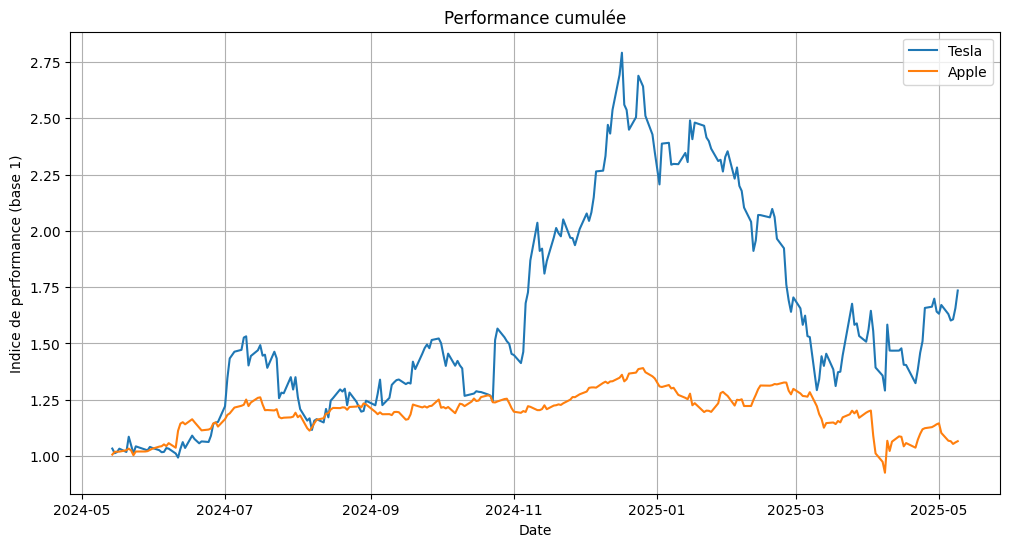

In [224]:
Tesla['Cumulative Return'] = (1 + Tesla['Return']).cumprod()
Apple['Cumulative Return'] = (1 + Apple['Return']).cumprod()

plt.figure(figsize=(12, 6))
plt.plot(Tesla['Date'], Tesla['Cumulative Return'], label='Tesla')
plt.plot(Apple['Date'], Apple['Cumulative Return'], label='Apple')
plt.title('Performance cumulée')
plt.xlabel('Date')
plt.ylabel('Indice de performance (base 1)')
plt.legend()
plt.grid(True)
plt.show()

# Synthèse

Ce graphique illustre la dynamique de la perfomance d'Apple et de Tesla, à partir d’un indice de base 1 au 1er janvier de la période concernée. La courbe de Tesla (en bleu) affiche ici de fortes variations : non seulement la valeur de l’action croît dans un premier temps rapidement et fortement, la poussant à plus de doubler sa valeur en début de période mais elle subit au début de l’année 2025 un net retournement qui la ramène sous un niveau de valeur plus modeste, mais supérieur à son niveau de départ. Ce cheminement atteste du caractère très volatile et spéculatif de Tesla, dont la dynamique de forte hausse s’accompagne de phases tout aussi voire plus nettes de repli.

La courbe d’Apple (en orange) semble suivre un mouvement beaucoup plus constant et mesuré. La performance cumulée devient croissante mais se renforce lentement, ne connaît pas de pics ni de chutes brutales, traduisant une évolution plus stable et donc plus prévisible. Pour un investisseur, l’opportunité d’acquérir une action Tesla peut offrir des gains importants, mais elle expose aussi à des pertes importantes rapides alors qu’avec une action Apple, la dynamique de croissance est plus régulière, mais rassurante. Ce type de représentation visuelle permet à la banque d’ajuster ses conseils à chaque client selon son profil de risque et à montrer l’intérêt d’un réseau de diversification des placements.

Les résultats de la comparaison des performances cumulées de Tesla et Apple révèlent clairement deux profils boursiers spécifiques. Tesla se distingue par une volatilité excessive puisque son indice de performance est en forte croissance ainsi qu’en forte correction, ce qui signifie un potentiel de performance élevé mais aussi un potentiel de risque important. En revanche, la hausse du titre Apple est beaucoup plus régulière et raisonnée, ce qui témoigne de la stabilité du titre et de la prévisibilité de ses rendements. Les conclusions sont harmonieusement en adéquation avec l’analyse statistique et graphique qui a été faite et où la dispersion des rendements est plus élevée et la volatilité supérieure pour Tesla.

Ce travail est tout particulièrement sensible à une banque afin d’élaborer, pour son propre client, une bonne analyse financière. Alors qu’elle veille sur la cotation boursière et présente sous forme graphique l’évolution de la performance, la banque doit procéder en fonction du profil de risque de son client : recommandant Tesla à un client dynamique et tolérant au risque, ou bien recommandant Apple si le client est plutôt en quête de sécurité. Cette analyse vient alors dire la qualité de service entre autres de la banque, contribue à fidéliser le client, et justifie également l’opportunité des recommandations que la banque réalise.

Pour aller plus loin, il serait pertinent d’élargir cette démarche à d’autres entreprises ou classes d’actifs et de mettre en place des outils d’alerte ou de suivi personnalisé pour accompagner les clients dans leurs choix d’investissement.

## Conclusion

La présente recherche comparative portant sur l’évaluation de la performance boursière de Tesla et d’Apple a permis de mettre à jour deux types de profils d’actions dont la dynamique présente des disparités marquées : active pour l’un, stable pour l’autre. En dissipant leurs doutes à partir de plusieurs indicateurs financiers (rendements, volatilité, performance cumulée), il est aisé pour la banque de prendre en compte les différents profils de ses clients pour lui apporter le conseil personnalisé adapté à son niveau de risque. Cet effort contribue à une meilleure qualité de service bancaire et à fidéliser le client. Poursuivant cette recherche sur d’autres entreprises et leur politique de communication comptable et les mettant à jour, la banque accompagne au mieux le client dans son choix d’investissement.